<a href="https://colab.research.google.com/github/lucssoares7/Mestrado/blob/main/SROncoNutri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instalação de Pacotes necessários para o projeto

In [126]:
pip install deap

In [127]:
pip install faker

In [128]:
pip install tabulate

In [129]:
pip install pandas

In [130]:
pip install scipy

In [131]:
!pip install torch transformers

In [132]:
!pip install topsispy

In [133]:
pip install -U pymoo

In [134]:
!pip install transformers datasets accelerate bitsandbytes


In [135]:
pip install tabulate

Montando o Drive para acesso ao diretório de Dados

In [136]:
def upper(df):
    df_maiusculo = df.applymap(lambda x: x.upper() if isinstance(x, str) else x)
    return df_maiusculo


In [137]:
from google.colab import drive
import pandas as pd
import csv
from datetime import datetime

# Montar o Google Drive
drive.mount('/content/drive')

# Caminho para o arquivo CSV original
drive_csv = '/content/drive/MyDrive/Colab Notebooks/Sistema de Recomendação/Dados/tbca.csv'

# Ler o arquivo CSV
df = pd.read_csv(drive_csv, engine='python', encoding='ISO-8859-1', sep=';')

# Converter nomes das colunas para maiúsculas
df.columns = [col.upper() for col in df.columns]

# Gerar o timestamp para o novo nome do arquivo
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
novo_arquivo_csv = f'/content/drive/MyDrive/Colab Notebooks/Sistema de Recomendação/Dados/tbca_maiusculas_{timestamp}.csv'

# Converter DataFrame para lista de dicionários
data = df.to_dict(orient='records')

# Salvar o DataFrame em um novo arquivo CSV usando DictWriter
with open(novo_arquivo_csv, 'w', encoding='ISO-8859-1', newline='') as arquivo_csv:
    escritor_csv = csv.DictWriter(arquivo_csv, fieldnames=df.columns)

    # Escrever o cabeçalho
    escritor_csv.writeheader()

    # Escrever os dados
    escritor_csv.writerows(data)

df = pd.read_csv(novo_arquivo_csv, engine='python', encoding='ISO-8859-1', sep=',')
# Exibir o DataFrame
print(df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
          ID                                           ALIMENTO  ENERGIA KJ  \
0     C0019D                  Óleo, abacate, Persea americana,       3700.0   
1     C0020D                    Óleo, algodão, Gossypium ssp.,       3700.0   
2     C0021D              Óleo, amendoim, Arachis hypogaea L.,       3700.0   
3     C0022D                        Óleo, arroz, Oryza sativa,       3700.0   
4     C0023D                  Óleo, babaçu, Orbignia martiana,       3700.0   
...      ...                                                ...         ...   
5263  C0180K                                    Xarope, milho,       1313.0   
5264  C0566F  Xinxim de bofe, c/ sal, (pulmão bovino, camarã...       739.0   
5265  C0573F  Xinxim de frango, c/ sal, (frango, camarão, ca...       938.0   
5266  C0893A  Yakisoba, c/ sal, (filé mignon bovino, peito d...       514.0   
52

Importando demais bibliotecas

In [138]:
# Bibliotecas científicas e númericas
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy import stats

# Processamento e manipulação de dados
from sklearn.preprocessing import MinMaxScaler
from itertools import combinations

# Bibliotecas de data e hora
from datetime import datetime, date, timedelta

# Geração de dados sintéticos
from faker import Faker
from faker.providers import person
import random
import pymoo
# Visualização
import matplotlib.pyplot as plt

# Otimização Multi-Objetivo - PyMOO
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.sampling import Sampling
from pymoo.core.crossover import Crossover
from pymoo.core.mutation import Mutation
from pymoo.core.evaluator import Evaluator
from pymoo.termination import get_termination
from pymoo.visualization.scatter import Scatter

# Operadores específicos PyMOO
from pymoo.operators.sampling.rnd import IntegerRandomSampling
from pymoo.operators.sampling.rnd import BinaryRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.crossover.pntx import TwoPointCrossover
from pymoo.operators.mutation.pm import PolynomialMutation
from pymoo.operators.mutation.bitflip import BitflipMutation


# Bibliotecas de computação evolutiva
from deap import base, creator, tools, algorithms

# Métodos de decisão multicritério
from topsispy import topsis

# Logging
import logging


Funções Auxiliares

In [139]:
def strToDate(data_string):
  formato_data = "%d/%m/%Y"
  return datetime.strptime(data_string, formato_data)

Definição da Classe Alimento

In [140]:
class Alimento:
    def __init__(self, codigoTBCA, descricao):
        self.codigoTBCA = codigoTBCA
        self.descricao = descricao

    def setKcal(self, kcal):
        self.kcal = kcal

    def setProteina(self, proteina):
        self.proteina = proteina

    def setCarboidrato(self, carboidrato):
        self.carboidrato = carboidrato

    def setLipidios(self, lipidios):
        self.lipidios = lipidios

    def getDescricao(self):
        return self.descricao

    def __str__(self):
        return f"Código: {self.codigoTBCA}, Descrição: {self.descricao}, Kcal: {self.kcal}, Proteína: {self.proteina}, Carboidrato: {self.carboidrato}, Lipídios: {self.lipidios}"


Calculadora de Macronutrientes

In [141]:
def determinar_grupo_etario(idade):
    """Determina o grupo etário com base na idade do paciente."""
    if idade <= 18:
        return 'pediatrico'
    elif idade >= 60:
        return 'idoso'
    else:
        return 'adulto'

def calcular_necessidades_nutricionais(peso, idade, imc, sexo, fase_tratamento, atividade_fisica, consistencia_alimentar):
    grupo_etario = determinar_grupo_etario(idade)

    # Seção 1: Macronutrientes
    macronutrientes = {}

    # Calorias e Proteínas Ajustadas à Fase de Tratamento
    if fase_tratamento == 'tratamento_ativo':
        # Necessidades aumentadas devido ao estresse metabólico
        calorias = 25 * peso
        proteinas = 1.5 * peso if imc < 30 else 2.0 * peso if imc < 40 else 2.5 * peso
    elif fase_tratamento == 'recuperacao':
        # Necessidades para reconstrução do estado nutricional
        calorias = 25 * peso
        proteinas = 1.2 * peso if imc < 30 else 1.5 * peso if imc >= 30 else 1.8 * peso
    elif fase_tratamento == 'manutencao_saude':
        # Manutenção da saúde com prevenção de recorrência e equilíbrio calórico
        calorias = 22 * peso
        proteinas = 1.0 * peso
    elif fase_tratamento == 'doenca_avancada':
        # Foco em conforto e palatabilidade
        calorias = 20 * peso
        proteinas = 0.8 * peso
    else:
        # Valor padrão caso fase de tratamento não seja especificada corretamente
        calorias = 0
        proteinas = 0

    macronutrientes['calorias'] = calorias
    macronutrientes['proteinas'] = proteinas

    # Gorduras e carboidratos
    gordura_total = (20, 35) if grupo_etario != 'pediatrico' else (30, 40)
    gordura_saturada = "<10% do VET"
    carboidratos = (50, 60)
    macronutrientes['gordura_total'] = gordura_total
    macronutrientes['gordura_saturada'] = gordura_saturada
    macronutrientes['carboidratos'] = carboidratos

    # Hidratação
    hidrico = 30 * peso if grupo_etario == 'adulto' else (25 * peso if grupo_etario == 'idoso' else
              (100 * peso if peso <= 10 else 1000 + 50 * (peso - 10) if peso <= 20 else 1500 + 20 * (peso - 20)))
    macronutrientes['hidrico'] = hidrico

    # Consistência alimentar
    refeicoes_diarias = consistencia_alimentar if consistencia_alimentar else 5
    macronutrientes['refeicoes_diarias'] = refeicoes_diarias
    macronutrientes['calorias_por_refeicao'] = round(calorias / refeicoes_diarias, 2)

    # Seção 2: Recomendações Específicas
    recomendacoes = {}
    recomendacoes['frutas_vegetais'] = "Consumir 3 porções de frutas e 3 porções de legumes/verduras, totalizando pelo menos 400 g/dia."
    recomendacoes['carne_vermelha'] = (
        "Para adultos: limitar a 500 g/semana e evitar carnes processadas. "
        "Para crianças/adolescentes: consumir até 3 porções/semana."
    )
    recomendacoes['alimentos_processados_e_sal'] = "Evitar alimentos processados e limitar o sal a 5 g/dia (2 g de sódio)."
    recomendacoes['alcool'] = (
        "Para adultos, limitar a 1 dose/dia para mulheres e 2 doses/dia para homens. "
        "Crianças, adolescentes e gestantes devem evitar o consumo de bebidas alcoólicas."
    )

    # Seção 3: Micronutrientes e Suplementos
    micronutrientes = {}
    micronutrientes['vitaminas'] = {
        'Vitamina C': "90 mg para homens, 75 mg para mulheres",
        'Vitamina D': "800 UI/dia se exposição solar insuficiente",
        'Zinco': "11 mg para homens, 8 mg para mulheres",
        'Ferro': "8 mg para homens, 18 mg para mulheres (ajustado conforme perda sanguínea)"
    }
    micronutrientes['suplementacao'] = (
        "Suplementação apenas em caso de carências nutricionais diagnosticadas."
    )

    return macronutrientes, recomendacoes, micronutrientes

# Exemplo de uso
peso = 70  # Peso em kg
altura = 1.75  # Altura em metros
idade = 65  # Idade em anos
imc = peso / (altura ** 2)  # Cálculo do IMC
sexo = 'F'  # Sexo do paciente
fase_tratamento = 'recuperacao'  # Fase do tratamento
atividade_fisica = 'Levemente Ativo'  # Nível de atividade física
consistencia_alimentar = 5  # Número de refeições diárias

macronutrientes, recomendacoes, micronutrientes = calcular_necessidades_nutricionais(
    peso, idade, imc, sexo, fase_tratamento, atividade_fisica, consistencia_alimentar
)

# Exibindo as necessidades nutricionais
print("Macronutrientes:")
for key, value in macronutrientes.items():
    print(f"{key.capitalize()}: {value}")

print("\nRecomendações Específicas:")
for key, value in recomendacoes.items():
    print(f"{key.capitalize()}: {value}")

print("\nMicronutrientes e Suplementos:")
for key, value in micronutrientes.items():
    print(f"{key.capitalize()}: {value}")


Macronutrientes:
Calorias: 1750
Proteinas: 84.0
Gordura_total: (20, 35)
Gordura_saturada: <10% do VET
Carboidratos: (50, 60)
Hidrico: 1750
Refeicoes_diarias: 5
Calorias_por_refeicao: 350.0

Recomendações Específicas:
Frutas_vegetais: Consumir 3 porções de frutas e 3 porções de legumes/verduras, totalizando pelo menos 400 g/dia.
Carne_vermelha: Para adultos: limitar a 500 g/semana e evitar carnes processadas. Para crianças/adolescentes: consumir até 3 porções/semana.
Alimentos_processados_e_sal: Evitar alimentos processados e limitar o sal a 5 g/dia (2 g de sódio).
Alcool: Para adultos, limitar a 1 dose/dia para mulheres e 2 doses/dia para homens. Crianças, adolescentes e gestantes devem evitar o consumo de bebidas alcoólicas.

Micronutrientes e Suplementos:
Vitaminas: {'Vitamina C': '90 mg para homens, 75 mg para mulheres', 'Vitamina D': '800 UI/dia se exposição solar insuficiente', 'Zinco': '11 mg para homens, 8 mg para mulheres', 'Ferro': '8 mg para homens, 18 mg para mulheres (ajust

In [142]:
def concatenar_lista(lista, delimitador=' '):
    return delimitador.join(lista)

Definição da Classe Paciente

In [143]:
import math

class Paciente:
  def __init__(self,nome,data_nascimento,peso_atual,sexo,altura,atividadeFisica):
    self.nome = nome
    self.data_nascimento = data_nascimento
    self.idade = 0
    self.peso_atual = peso_atual
    self.sexo = sexo
    self.altura = altura
    self.atividadeFisica = None
    self.tmb = None
    self.proteinas = None
    self.carboidratos = None
    self.gorduras = None
    self.alergias = []
    self.intolerancias = []
    self.suplementos_alimentares = []
    self.calorias_refeicao = []
    self.alimentos_indigestos = []
    self.alimentos_preferidos = []
    self.imc = None

  def calcular_idade(self):
  # Obter a data atual
    data_de_hoje = date.today()
    # Calcula a diferença entre as datas para obter a idade
    diferenca_anos = data_de_hoje.year - self.data_nascimento.year
    if (data_de_hoje.month, data_de_hoje.day) < (self.data_nascimento.month, self.data_nascimento.day):
      diferenca_anos -= 1
    self.idade = diferenca_anos

  def setNome(self,nome):
    self.nome = nome
  def setPeso_atual(self,peso_atual):
    self.peso_atual = peso_atual
  def setSexo(self,sexo):
    self.sexo = sexo

  def setAltura(self,altura):
    self.altura = altura
  def setdata_nascimento(self, data_nascimento):
    self.data_nascimento = strToDate(data_nascimento)
    data_de_hoje = date.today()
  def getSexo(self):
    return self.sexo
  def getPeso_atual(self):
    return self.peso_atual
  def getAltura(self):
    return self.altura
  def setdata_diagnostico(self, data_diagnostico):
        self.data_diagnostico = data_diagnostico
  def set_peso_diagnostico(self, peso_diagnostico):
      self.peso_diagnostico = peso_diagnostico

  def set_peso_mes_passado(self, peso_mes_passado):
      self.peso_mes_passado = peso_mes_passado

  def set_peso_3_meses_passados(self, peso_3_meses_passados):
      self.peso_3_meses_passados = peso_3_meses_passados

  def set_patologias_atuais(self, patologias_atuais):
      self.patologias_atuais = patologias_atuais

  def set_fitoterapico_em_uso(self, fitoterapico_em_uso):
      self.fitoterapico_em_uso = fitoterapico_em_uso

  def set_cirurgias(self, cirurgias):
      self.cirurgias = cirurgias

  def set_fase_tratamento(self, fase_tratamento):
      self.fase_tratamento = fase_tratamento

  def set_tabagismo(self, tabagismo):
      self.tabagismo = tabagismo

  def set_etilismo(self, etilismo):
      self.etilismo = etilismo

  def set_chimarrao(self, chimarrao):
      self.chimarrao = chimarrao

  def set_consistencia_alimentar_aceita(self, consistencia_alimentar_aceita):
      self.consistencia_alimentar_aceita = consistencia_alimentar_aceita
  def set_medicamentos(self,medicamentos):
      self.medicamentos = medicamentos

  def set_data_nascimento(self, data_nascimento):
      self.data_nascimento = data_nascimento

  def set_atividade_fisica(self, atividadeFisica):
      self.atividadeFisica = atividadeFisica
  def get_atividade_fisica(self):
      return self.atividadeFisica
  def set_alimentospreferidos(self,alimentos_preferidos_escolhidos):
      self.alimentos_preferidos = alimentos_preferidos_escolhidos
  def set_alimentosindigestos(self, alimentos_indigestos_escolhidos):
      self.alimentos_indigestos = alimentos_indigestos_escolhidos
  def getAlimentosindigestos(self):
      return self.alimentos_indigestos
  def getAlimentospreferidos(self):
      return self.alimentos_preferidos
  def getNome(self):
    return self.nome
  def getIdade(self):
    return self.idade
  def setNecessidadesNutricionais(self):
      self.imc = self.peso_atual / (self.altura ** 2) if self.altura else None

      macronutrientes, recomendacoes, micronutrientes = calcular_necessidades_nutricionais(
          self.peso_atual, self.idade, self.imc, self.sexo, self.fase_tratamento, self.atividadeFisica, self.consistencia_alimentar_aceita
      )
      self.tmb = macronutrientes.get('calorias', 0)
      self.proteinas = round(macronutrientes['proteinas'],2)
      self.calorias_refeicao = round(macronutrientes['calorias_por_refeicao'],2)
      self.carboidratos = round(macronutrientes['carboidratos'][0],2)
      self.gorduras = round(macronutrientes['gordura_total'][0],2)
  def getTMB(self):
    return self.tmb
  def getConsistencia_alimentar_aceita(self):
    return self.consistencia_alimentar_aceita

  #media de calorias por refeição
  def setCalorias_refeicao(self):
    for i in range(self.consistencia_alimentar_aceita):
      aux = self.tmb / self.consistencia_alimentar_aceita
      aux = round(aux,2)
      self.calorias_refeicao.append(aux)

  def getCalorias_refeicao(self):
    return self.calorias_refeicao

  def setAtividadeFisica(self,atividadeFisica):
    self.atividadeFisica = atividadeFisica

  def setAlergias(self, alergias):
    self.alergias.append(alergias)
    #self.alergias.sort()  # Ordenar em ordem alfabética

  def setIntolerancias(self, intolerancias):
    self.intolerancias.append(intolerancias)
    #self.intolerancias.sort()  # Ordenar em ordem alfabética
  def getIntolerancias(self):
    return self.intolerancias
  def getAlergias(self):
    return self.alergias

  def setSuplementos(self, suplementos):
    self.suplementos_alimentares = suplementos
    #self.suplementos_alimentares.sort()  # Ordenar em ordem alfabética

  #def __str__(self):
  #      return f"Nome: {self.nome}, Sexo: {self.sexo}, Peso: {self.peso_atual} kg, Altura: {self.altura} cm, Idade: {self.idade} anos, Atividade física: {self.atividadeFisica}, Taxa de metabolismo Basal: {self.tmb} Kcals"
  def __str__(self):
    #patologias_atuais_str = ', '.join(f"{chave}: {valor}" for chave, valor in self.patologias_atuais.items())
    return (
        f"Nome: {self.nome}, "
        f"Data de Nascimento: {self.data_nascimento}, "
        f"Peso Atual(kg): {self.peso_atual}, "
        f"Data do Diagnóstico: {self.data_diagnostico}, "
        f"Peso na Data do Diagnóstico (kg): {self.peso_diagnostico}, "
        f"Peso há 1 mês (kg): {self.peso_mes_passado}, "
        f"Peso há 3 meses (kg): {self.peso_3_meses_passados}, "
        f"Altura (m): {self.altura}, "
        f"Sexo: {self.sexo}, "
        f"Atividade Física: {self.atividadeFisica}, "
        f"Patologias Atuais: {self.patologias_atuais}, "
        f"Medicamentos em Uso: {self.medicamentos}, "
        f"Fitoterapicos: {self.fitoterapico_em_uso}, "
        f"Cirurgias: {self.cirurgias}, "
        f"Fase do Tratamento Oncológico: {self.fase_tratamento}, "
        f"Tabagismo: {self.tabagismo}, "
        f"Etilismo: {self.etilismo}, "
        f"Chimarrao: {self.chimarrao}, "
        f"Consistência Alimentar aceita: {self.consistencia_alimentar_aceita} Refeições/dia, "
        f"Taxa de Metabolismo Basal: {self.tmb} Kcals/dia, "
        f"Média de calorias por refeição: {self.tmb/self.consistencia_alimentar_aceita}, "
        f"Alimentos Preferidos: {self.alimentos_preferidos}, "
        f"Alimentos Indigestos:{self.alimentos_indigestos}, "
        f"Alergias: {self.alergias}, "
        f"Intolerâncias: {self.intolerancias}, "
        f"Suplementos Alimentares: {self.suplementos_alimentares}"
    )

  def converter_latex(self):
    # Função para formatar datas
    def formatar_fase_tratamento(fase):
        mapeamento_fases = {
            'tratamento_ativo': 'Tratamento Ativo',
            'recuperacao': 'Recuperação',
            'manutencao_saude': 'Manutenção da Saúde',
            'doenca_avancada': 'Doença Avançada'
        }

        # Retorna o nome formatado ou a fase original se não encontrado
        return mapeamento_fases.get(fase, fase)
    def formatar_data(data):
        if isinstance(data, str):
            return data.split()[0]  # Remove horas
        return str(data).split()[0]  # Remove horas se for datetime

    def arredondar(valor):
        return round(float(valor), 2)


    # Tratamento de listas para string
    def formatar_lista(lista):
        if not lista:
            return ''
        # Remove aspas e caracteres especiais
        return ', '.join(str(item).replace("'", "").strip() for item in lista)

    # Preparar strings de alimentos
    alimentos_preferidos_str = formatar_lista(self.alimentos_preferidos)
    alimentos_indigestos_str = formatar_lista(self.alimentos_indigestos)

    # Preparar dados do paciente com tratamentos
    dados_paciente = {
        'Atributo': [
            'Nome', 'Data de Nascimento', 'Data do Diagnóstico',
            'Peso na Data do Diagnóstico (kg)', 'Peso há 3 meses (kg)',
            'Peso há 1 mês (kg)', 'Peso Atual (kg)', 'Altura (m)',
            'Sexo', 'Atividade Física', 'Patologias Atuais',
            'Medicamentos em Uso', 'Fitoterapicos', 'Cirurgias',
            'Fase do Tratamento Oncológico', 'Tabagismo', 'Etilismo',
            'Chimarrao', 'Consistência Alimentar aceita',
            'Taxa de Metabolismo Basal', 'Média de calorias por refeição',
            'Alimentos Preferidos', 'Alimentos Indigestos',
            'Alergias', 'Intolerâncias', 'Suplementos Alimentares'
        ],
        'Valor': [
            self.nome,
            formatar_data(self.data_nascimento),
            formatar_data(self.data_diagnostico),
            arredondar(self.peso_diagnostico),
            arredondar(self.peso_3_meses_passados),
            arredondar(self.peso_mes_passado),
            arredondar(self.peso_atual),
            arredondar(self.altura),
            str.upper(self.sexo),
            self.atividadeFisica,
            self.patologias_atuais,
            formatar_lista(self.medicamentos),
            self.fitoterapico_em_uso,
            self.cirurgias,
            formatar_fase_tratamento(self.fase_tratamento),
            self.tabagismo,
            self.etilismo,
            self.chimarrao,
            self.consistencia_alimentar_aceita,
            f"{arredondar(self.tmb)} Kcals/dia",
            f"{arredondar(self.tmb / self.consistencia_alimentar_aceita)} Kcals/refeição",
            alimentos_preferidos_str,
            alimentos_indigestos_str,
            formatar_lista(self.alergias),
            formatar_lista(self.intolerancias),
            self.suplementos_alimentares
        ]
    }

    # Criar DataFrame
    df = pd.DataFrame(dados_paciente)

    # Configurações adicionais para exportação LaTeX
    tabela_latex = df.to_latex(
        index=False,
        escape=True,  # Escape caracteres especiais do LaTeX
        column_format='l|p{10cm}'  # Formato de coluna personalizado
    )

    return tabela_latex




Definição de Tipos de Medicamentos e Restrições

In [144]:
tipos_cancer_medicamentos = {
    'Câncer de Pele Não Melanoma': ['Cirurgia', 'Terapia Fotodinâmica', 'Imiquimode'],
    'Câncer de Mama': ['Trastuzumab', 'Tamoxifeno', 'Paclitaxel', 'Capecitabina', 'Docetaxel'],
    'Câncer de Próstata': ['Bicalutamida', 'Leuprorelina', 'Enzalutamida', 'Docetaxel'],
    'Câncer Colorretal': ['Fluorouracil', 'Oxaliplatina', 'Capecitabina', 'Irinotecano'],
    'Câncer de Pulmão': ['Cisplatina', 'Carboplatina', 'Paclitaxel', 'Vinorelbina', 'Pembrolizumabe'],
    'Câncer de Estômago': ['Cisplatina', 'Paclitaxel', 'Capecitabina', 'Trastuzumab'],
    'Câncer de Colo do Útero': ['Cisplatina', 'Bevacizumabe', 'Radioterapia'],
    'Câncer de Cavidade Oral': ['Cisplatina', 'Fluorouracil', 'Cetuximabe', 'Radioterapia'],
    'Câncer de Tireoide': ['Levotiroxina', 'Sorafenibe', 'Lenvatinibe'],
    'Câncer de Fígado': ['Sorafenibe', 'Lenvatinibe']
}



fitoterapicos = [
    'Nenhum',
    'Alcachofra (Cynara scolymus L.)',
    'Aroeira (Schinus terebinthifolius Raddi)',
    'Babosa (Aloe vera (L.) Burm.f )',
    'Cáscara-sagrada (Rhamnus purshiana D.C.)',
    'Espinheira-santa (Maytenus officinalis Mabb.)',
    'Guaco (Mikania glomerata Spreng.)',
    'Garra-do-diabo (Harpagophytum procumbens)',
    'Hortelã (Mentha x piperita L.)',
    'Isoflavona de soja (Glycine max (L.) Merr.)',
    'Plantago (Plantago ovata Forssk.)',
    'Salgueiro (Salix alba L.)',
    'Unha-de-gato (Uncaria tomentosa (Willd. ex Roem. & Schult.)'
]

tipos_cirurgia = [
    'Nenhuma',
    'Cirurgia Primária ou Curativa (Remoção do Tumor)',
    'Cirurgia Diagnóstica (Biópsia)',
    'Cirurgia de Estadiamento',
    'Cirurgia Debulking (Cirurgia Citorredutora)',
    'Cirurgia Paliativa',
    'Cirurgia Reconstrutora',
    'Cirurgia Preventiva'
]


fases_tratamento = {
    'tratamento_ativo': [
        'Diagnóstico',
        'Consulta Médica',
        'Planejamento do Tratamento',
        'Dosimetria (Radioterapia)',
        'Simulação do Tratamento (Radioterapia)',
        'Aplicação do Tratamento'
    ],
    'recuperacao': [
        'Pós-tratamento'
    ],
    'manutencao_saude': [
        'Prevenção de Recorrência',
        'Acompanhamento Regular'
    ],
    'doenca_avancada': [
        'Cuidados Paliativos',
        'Tratamento de Suporte'
    ]
}


tipos_atividade_fisica =[
    'Sedentario',
    'Levemente Ativo',
    'Moderadamente Ativo',
    'Altamente Ativo',
    'Extremamente Ativo'
]

# Lista de alergias
tipos_alergias = [
    'AMENDOIM', 'MARISCOS', 'TRIGO', 'GLÚTEN', 'OVO', 'NOZES', 'CASTANHAS',
    'PEIXE', 'CAMARÃO', 'FRUTAS CÍTRICAS', 'LEITE', 'SOJA', 'CHOCOLATE',
    'MORANGO', 'BANANA', 'ABACATE'
]

# Lista de intolerâncias
tipos_intolerancias = [
    'LACTOSE', 'CARNE', 'PORCO', 'GLÚTEN', 'FRUTAS CÍTRICAS', 'OVO',
    'PEIXE', 'SOJA', 'MILHO', 'NOZES', 'AMENDOIM', 'CHOCOLATE', 'CAFÉ'
]



tipos_suplementos_alimentares = [
    'vitamina D', 'vitamina C', 'ferro', 'cálcio', 'proteína em pó', 'ômegas-3', 'multivitamínico', 'colágeno',
    'zinco', 'magnésio', 'vitamina B12', 'vitamina E', 'glutamina', 'BCAA', 'creatina', 'prebióticos', 'probióticos',
    'arginina', 'carnitina', 'coenzima Q10', 'glucosamina', 'condroitina', 'melatonina', 'curcumina', 'ginseng',
    'espirulina', 'spirulina', 'quitosana', 'lecitina', 'cúrcuma', 'óleo de peixe', 'óleo de prímula',
    'beta-alanina', 'dhea', 'l-carnitina', 'tart cherry', 'vitamina K2', 'proteína vegetal', 'colina',
    'resveratrol', 'ácido hialurônico', 'proteína de arroz', 'proteína de ervilha', 'glutamato de monossódio',
    'inositol', 'betacaroteno', 'proteína de soja', 'fenilalanina', 'glutamato', 'tiamina', 'riboflavina',
    'vitamina A', 'vitamina B6', 'vitamina K', 'selênio', 'iodo', 'potássio', 'manganês', 'cromo', 'molibdênio',
    'ácido fólico', 'ácido pantotênico', 'biotina', 'colina', 'cobre', 'ferro heme', 'ferro não heme', 'magnésio',
    'manganês', 'molibdênio', 'selênio', 'zinco', 'ácido alfa-lipóico', 'ácido fólico', 'betaína', 'carnosina',
    'cisteína', 'flavonoides', 'luteína', 'zeaxantina', 'polifenóis', 'proantocianidinas', 'quercetina',
    'resveratrol', 'saponinas', 'sulforafano', 'tirosina', 'triptofano', 'valina', 'álcool polivinílico',
    'arginina alfa-cetoglutarato', 'chondrus crispus', 'citrus bioflavonoides', 'colecalsiferol', 'creatina etil éster',
    'hidroximetilbutirato', 'l-carnitina tartrato', 'leucina', 'malato de citrulina', 'ornitina alfa-cetoglutarato',
    'peptídeos de colágeno', 'proteína de ovo', 'raiz de dente-de-leão', 'sílica', 'trimetilglicina', 'ubiquinol',
    'zeína', 'zingerona', 'óleo de alho', 'óleo de gérmen de trigo', 'óleo de linhaça', 'óleo de prímula',
    'óleo de semente de abóbora', 'óleo de semente de uva', 'óleo de peixe ômega-3', 'óleo de krill',
    'óleo de fígado de bacalhau', 'óleo de borragem', 'óleo de cártamo', 'óleo de cártamo com vitamina E',
    'óleo de coco', 'óleo de semente de chia', 'óleo de semente de groselha negra', 'óleo de oliva', 'óleo de gergelim',
    'óleo de onagra', 'óleo de noz', 'óleo de alga', 'óleo de palma', 'óleo de abacate', 'óleo de rícino',
    'óleo de amêndoas', 'óleo de macadâmia', 'óleo de pistache', 'óleo de colza', 'óleo de cenoura',
    'óleo de cártamo com vitamina E', 'óleo de semente de abóbora', 'óleo de semente de uva', 'óleo de peixe ômega-3',
    'óleo de krill', 'óleo de fígado de bacalhau', 'óleo de borragem', 'óleo de cártamo', 'óleo de cártamo com vitamina E',
    'óleo de coco', 'óleo de semente de chia', 'óleo de semente de groselha negra', 'óleo de oliva', 'óleo de gergelim',
    'óleo de onagra', 'óleo de noz', 'óleo de alga', 'óleo de palma', 'óleo de abacate', 'óleo de rícino', 'óleo de amêndoas',
    'óleo de macadâmia', 'óleo de pistache', 'óleo de colza', 'óleo de cenoura'
]

tipos_habito_intestinal = []

tipos_habito_urinario = []

Classe Tabela de Alimentos

In [145]:
import os
import csv
import numpy as np
from tabulate import tabulate
from itertools import groupby
import pandas as pd

nome_arquivo_saida = "alimentos_possiveis.csv"

class TabelaAlimentos:
    def __init__(self, nome_arquivo):
        self.nome_arquivo = nome_arquivo
        #self.colunas_relevantes = ['ALIMENTO', 'Energia Kcal', 'Proteína', 'carboidrato total', 'Lipídios']
        self.colunas_relevantes = [
            'ID', 'ALIMENTO', 'Energia KJ', 'Energia Kcal', 'Umidade g',
            'carboidrato total', 'carboidrato disponível', 'Proteína',
            'Lipídios', 'Fibra alimentar', 'Álcool', 'Cinzas', 'Colesterol',
            'Ácidos graxos saturados', 'Ácidos graxos monoinsaturados',
            'Ácidos graxos polinsaturados', 'Ácidos graxos trans', 'Cálcio',
            'Ferro', 'Sódio', 'Magnésio', 'Fósforo', 'Potássio', 'Zinco',
            'Cobre', 'Selênio', 'Vitamina A (RE)', 'Vitamina A (RAE)',
            'Vitamina D', 'Alfa-tocoferol (Vitamina E)', 'Tiamina', 'Riboflavina',
            'Niacina', 'Vitamina B6', 'Vitamina B12', 'Vitamina C',
            'Equivalente de folato', 'Sal de adição', 'Açúcar de adição',
            'Tipo', 'Estado'
        ]
        self.colunas_relevantes = [col.upper() for col in self.colunas_relevantes]
        self.dados = self.carregar_dados()
        self.grupos = {
          "Cereais, Pães, Tubérculos e Raízes": [
              "ARROZ", "PÃO", "MASSA", "BATATA", "MANDIOCA", "MILHO", "FARINHA","BISCOITO SAlGADO","CANELONE","CUSCUZ","CEREAL","CEREAIS","PANQUECA","PIZZA","TORRADA","WAFFLE","PASTEL"
              "TRIGO", "AVEIA", "CEVADA", "QUINOA", "BATATA-DOCE", "INHAME", "COUSCOUS", "PIPOCA","TORTA", "FAROFA","LASANHA","MACARRÃO","SEMENTE","TAPIOCA","SANDUICHE","SANDUÍCHE","PÃO DE ALHO","TORTEI","RONDELE","RAVIOLI","PURÊ"
          ],
          "Hortaliças (Legumes e Verduras)": [
            "ALFACE", "TOMATE", "CENOURA", "BRÓCOLIS", "ESPINAFRE", "PEPINO","CEBOLA","COGUMELO","LEGUMES","PIMENTÃO",
              "ABOBRINHA", "COUVE", "COUVE-FLOR", "RÚCULA", "NABO", "BETERRABA", "REPOLHO", "CHUCHU", "ALHO-PORÓ", "ABÓBORA","VEGETAIS","SALADA","BETERRABA","BERINJELA","ACELGA","AGRIÃO","ALMEIRÃO","QUIABO"
          ],
          "Frutas": [
              "MAÇÃ", "BANANA", "LARANJA", "MORANGO", "UVA", "PERA", "MANGA",
              "MELANCIA", "MARACUJÁ", "ABACAXI", "KIWI", "PÊSSEGO", "GOIABA","TANGERINA"
              "AMEIXA", "FIGO", "FRAMBOESA", "CEREJA", "ABACATE","ACEROLA","CAJU","JACA","CAJA","MAMÃO","ROMÃ"
          ],
          "Leite e Derivados": [
              "LEITE", "QUEIJO", "IOGURTE", "MANTEIGA", "REQUEIJÃO", "CREME DE LEITE",
              "RICOTA", "LEITE CONDENSADO", "LEITE EM PÓ", "COALHADA","MUÇARELA"
          ],
          "Carnes e Ovos": [
              "CARNE", "FRANGO", "OVO","PORCO", "BOI", "FRANGO", "PEITO DE PERU", "HAMBÚRGUER", "TOFU","OVOS",
              "SOJA", "ERVILHA", "BACON","STROGONOFF", "STEAK","BACON","ROUPA VELHA","CHARQUE","APRESUNTADO","BIFE","CHURRASQUINHO","DOBRADINHA","OMELETE","PAPA DE FÍGADO","PAPA DE PEITO","FÍGADO"
          ],
          "Leguminosas":[
               "FEIJÃO", "LENTILHA", "GRÃO-DE-BICO","VAGEM","ERVILHA","SOHA"
          ],
          "Óleos e Gorduras": [
              "ÓLEO", "AZEITE", "MANTEIGA", "MARGARINA", "NOZES",
              "CASTANHA", "AMÊNDOAS", "SEMENTE DE GIRASSOL", "SEMENTE DE LINHAÇA",
              "SEMENTE DE ABÓBORA", "BANHA", "ÓLEO DE COCO","CREME","MAIONESE","AMENDOIM","AMÊNDOAS","SEMENTE DE GIRASSOL","SEMENTE DE LINHAÇA","SEMENTE DE ABÓBORA","BANHA","ÓLEO DE COCO"
          ],
          "Açúcares e Doces": [
              "AÇÚCAR", "MEL", "DOCE", "CHOCOLATE", "SORVETE","BOMBOM",
              "BALAS", "BISCOITO RECHEADO", "TORTA", "BOLO", "PUDIM", "GELATINA","BISCOITO DOCE","MARIA MOLE"
              "GOMAS DE MASCAR", "CREME DE AVELÃ", "GELÉIA","ADOÇANTE","BALA","XAROPE","SUNDAE","CARAMELO","ACHOCOLATADO","BRIGADEIRO","CANUDINHO","CHURROS","BOMBA","DOCE","ARROZ DOCE"
          ],
          "Peixes e Frutos do Mar": [
              "PEIXE", "CAMARÃO", "MARISCO", "SIRI", "LULA", "POLVO",
              "SALMÃO", "ATUM", "BACALHAU", "TRUTA", "TILÁPIA", "SARDINHA",
              "CAVALA", "ANCHOVA", "OSTRA", "MEXILHÃO","FRUTOS DO MAR"
          ],
          "Bebidas":[
              "BEBIDA","DRINK","BEBIDA ALCOÓLICA","REFRIGERANTE","CAFÉ","ALCOÓLICA","SUCO","ÁGUA","ACHOCOLATADO"
          ],
          "Temperos_complementos":['VINAGRE','LIMÃO','SAL','KETCHUP','MOSTARDA','MOLHO','CREAM CHESSE', 'CRAVO']
        }

    def carregar_dados(self):
        try:
            with open(self.nome_arquivo, newline='', mode='r', encoding='ISO-8859-1') as arquivo_csv:
                leitor_csv = csv.DictReader(arquivo_csv, delimiter=',')
                dados_upper = []

                for linha in leitor_csv:
                    linha_processada = {}
                    for coluna, valor in linha.items():
                        if coluna == 'ALIMENTO' or coluna == 'TIPO':
                            linha_processada[coluna] = valor.upper() if valor else valor
                        else:
                            linha_processada[coluna] = valor

                    dados_upper.append(linha_processada)

                # Ordenar dados pela coluna 'ALIMENTO'
                dados_ordenados = sorted(dados_upper, key=lambda x: x.get('ALIMENTO', '').upper())

            return dados_ordenados

        except FileNotFoundError:
            print(f"Erro: Arquivo {self.nome_arquivo} não encontrado.")
        except Exception as e:
            print(f"Ocorreu um erro: {e}")


    def definir_estado_fisico(self):
        # Dicionário de palavras-chave para estados físicos
        estados = {
            "SÓLIDO": ["PÃO", "QUEIJO", "CARNE", "FRANGO", "BATATA", "ARROZ", "MASSA", "FRUTA", "LEGUME"],
            "LÍQUIDO": ["LEITE", "ÁGUA", "SUCO", "REFRIGERANTE", "BEBIDA", "CAFÉ" "CALDO", "SOPA", "IOGURTE", "VINHO"]
        }

        for alimento in self.dados:
            nome = alimento.get('ALIMENTO', '').upper().strip()  # Garante que o nome esteja em uppercase e sem espaços extras
            estado_definido = False

            # Verifica se o nome do alimento contém uma palavra-chave associada a um estado físico
            for estado, palavras_chave in estados.items():
                if any(palavra in nome for palavra in palavras_chave):
                    alimento['ESTADO'] = estado  # Atribui o estado físico correspondente
                    estado_definido = True
                    break

            if not estado_definido:
                alimento['ESTADO'] = "DESCONHECIDO"  # Caso o estado físico não seja identificado

    def exibir_todos_os_dados(self, max=100):
        for linha in self.dados[:max]:
            print(linha)

    def getnomesAlimentos(self):
        return [alimento.get('ALIMENTO', '').strip() for alimento in self.dados]

    def getlistaAlimentos(self):
        return self.dados

    def adicionar_alimento(self, novo_alimento):
        if novo_alimento:
            self.dados.append({coluna: novo_alimento[coluna] for coluna in self.colunas_relevantes})
            self.salvar_dados(self.gerar_nome_arquivo())

    def preencher(self, lista_alimentos):
        #self.colunas_relevantes = ['ALIMENTO', 'Energia Kcal', 'Proteína', 'carboidrato total', 'Lipídios']
        '''
        self.colunas_relevantes = [
            'ID', 'ALIMENTO', 'Energia KJ', 'Energia Kcal', 'Umidade g',
            'carboidrato total', 'carboidrato disponível', 'Proteína',
            'Lipídios', 'Fibra alimentar', 'Álcool', 'Cinzas', 'Colesterol',
            'Ácidos graxos saturados', 'Ácidos graxos monoinsaturados',
            'Ácidos graxos polinsaturados', 'Ácidos graxos trans', 'Cálcio',
            'Ferro', 'Sódio', 'Magnésio', 'Fósforo', 'Potássio', 'Zinco',
            'Cobre', 'Selênio', 'Vitamina A (RE)', 'Vitamina A (RAE)',
            'Vitamina D', 'Alfa-tocoferol (Vitamina E)', 'Tiamina', 'Riboflavina',
            'Niacina', 'Vitamina B6', 'Vitamina B12', 'Vitamina C',
            'Equivalente de folato', 'Sal de adição', 'Açúcar de adição',
            'Tipo', 'Estado'
        ]
        self.colunas_relevantes = [col.upper() for col in self.colunas_relevantes]
        '''
        self.dados = lista_alimentos
        self.salvar_dados(self.gerar_nome_arquivo())

    def removerAlimento(self, lista_alimentos_restritos):

        alimentos_atualizados = []
        for alimento in self.dados:
            if alimento not in lista_alimentos_restritos:
                alimentos_atualizados.append(alimento)
        self.dados = alimentos_atualizados
        nome_arquivo_saida = self.gerar_nome_arquivo()
        self.salvar_dados(nome_arquivo_saida)
        return nome_arquivo_saida

    def salvar_dados(self, nome_arquivo_saida=None):
        with open(nome_arquivo_saida, 'w', encoding='ISO-8859-1', newline='') as arquivo_csv:
            escritor_csv = csv.DictWriter(arquivo_csv, fieldnames=self.colunas_relevantes)
            escritor_csv.writeheader()
            escritor_csv.writerows(self.dados)

    def gerar_nome_arquivo(self):
        nome_base, extensao = os.path.splitext(self.nome_arquivo)
        timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
        novo_nome = f"{nome_base}_atualizado_{timestamp}{extensao}"
        return novo_nome

    def buscar_kcal(self, ID, unidades):
        unidades = round(unidades, 3)
        for alimento in self.dados:
            if alimento['ID'] == ID:
                nome = alimento['ALIMENTO']
                kcal_por_unidade = float(alimento['ENERGIA KCAL'].replace(',', '.'))
                kcal_total = round(kcal_por_unidade * unidades)
                return nome[:15], kcal_por_unidade, unidades, kcal_total
        return None

    def gerar_tabela_latex(self):
        dados_formatados = [{coluna: alimento[coluna] for coluna in self.colunas_relevantes} for alimento in self.dados]
        return tabulate(dados_formatados, headers="keys", tablefmt="latex_raw")

    def agruparTipo(self):
        dados_ordenados_por_tipo = sorted(self.dados, key=lambda x: x['TIPO'])
        grupos_tipos = {}
        for tipo, alimentos_do_tipo in groupby(dados_ordenados_por_tipo, key=lambda x: x['TIPO']):
            grupos_tipos[tipo] = list(alimentos_do_tipo)
        return grupos_tipos

    def gerar_tabelas_latex_por_tipo(self):
        grupos_por_tipo = self.agruparTipo()
        tabelas_latex = {}
        for tipo, alimentos in grupos_por_tipo.items():
            dados_formatados = [{coluna: alimento[coluna] for coluna in self.colunas_relevantes} for alimento in alimentos]
            tabelas_latex[tipo] = tabulate(dados_formatados, headers="keys", tablefmt="latex_raw")
        return tabelas_latex

    def dividir_valores_por_10(self):
        colunas_numericas = [
            'Energia KJ', 'Energia Kcal', 'Umidade g',
            'carboidrato total', 'carboidrato disponível', 'Proteína',
            'Lipídios', 'Fibra alimentar', 'Álcool', 'Cinzas', 'Colesterol',
            'Ácidos graxos saturados', 'Ácidos graxos monoinsaturados',
            'Ácidos graxos polinsaturados', 'Ácidos graxos trans', 'Cálcio',
            'Ferro', 'Sódio', 'Magnésio', 'Fósforo', 'Potássio', 'Zinco',
            'Cobre', 'Selênio', 'Vitamina A (RE)', 'Vitamina A (RAE)',
            'Vitamina D', 'Alfa-tocoferol (Vitamina E)', 'Tiamina', 'Riboflavina',
            'Niacina', 'Vitamina B6', 'Vitamina B12', 'Vitamina C',
            'Equivalente de folato', 'Sal de adição', 'Açúcar de adição'
        ]

        colunas_numericas = [col.upper() for col in colunas_numericas]
        for alimento in self.dados:
            for coluna in colunas_numericas:
                if coluna in alimento:
                    valor = alimento[coluna]
                    if valor in ['tr', 'NA', '', None, 'NaN']:
                        alimento[coluna] = '0'  # Substitui por '0'
                    else:
                        try:
                            # Substitui vírgula por ponto, converte para float, divide por 10 e arredonda para 3 casas
                            alimento[coluna] = str(round(float(valor.replace(',', '.')) / 10, 3))
                        except ValueError:
                            # Tratar valores não numéricos (se houver) que não foram capturados anteriormente
                            pass

    def classificar_alimentos(self):
        """
        Classifica os alimentos com base em palavras-chave, priorizando `nome1` sobre `nome2`.
        """
        stopwords = {"DE", "EM", "NO", "NA", "DA", "DO", "COM", "PARA", "A", "O", "E", "IN"}
        self.grupos = {chave.upper(): [item.upper() for item in valores] for chave, valores in self.grupos.items()}

        for alimento in self.dados:
            nome = alimento.get('ALIMENTO', '').upper().strip()
            nomes = [palavra for palavra in nome.split() if palavra not in stopwords]
            nome1 = nomes[0] if nomes else ''
            if nome1.endswith(','):
                nome1 = nome1[:-1]

            nome2 = nomes[1] if len(nomes) > 1 else ''
            if nome2.endswith(','):
                nome2 = nome2[:-1]

            alimento['TIPO'] = "OUTROS"  # Inicializa como "OUTROS"
            grupo_encontrado = ''

            # Verifica `nome1` nos grupos
            for grupo in self.grupos:
                if nome1 in self.grupos[grupo]:
                    grupo_encontrado = grupo
                    alimento['TIPO'] = grupo_encontrado
                    break

            # Se `nome1` não encontrou, verifica `nome2`
            if not grupo_encontrado and nome2:
                for grupo, palavras_chave in self.grupos.items():
                    if nome2 in palavras_chave:
                        grupo_encontrado = grupo
                        alimento['TIPO'] = grupo_encontrado
                        break

            if not grupo_encontrado:
                alimento['TIPO'] = "OUTROS"
            # Depuração
            #print(nome1, '-', nome2, '-', grupo_encontrado)


    def gerar_matriz_nutricional(self):
        matriz_nutricional = [
            [alimento['ALIMENTO'],
             float(alimento['Energia Kcal'].replace(',', '.')),
             float(alimento['Proteína'].replace(',', '.')),
             float(alimento['carboidrato total'].replace(',', '.')),
             float(alimento['Lipídios'].replace(',', '.')),
             float(alimento['Fibra alimentar'].replace(',', '.'))]
            for alimento in self.dados
        ]
        return np.array(matriz_nutricional)

    def copy(self):
        return TabelaAlimentos(self.nome_arquivo)
    def buscarAlimentosRestritos(self, lista_alimentos_restritos):
        # Verifica se a lista de alimentos restritos é válida
        if not isinstance(lista_alimentos_restritos, list):
            raise ValueError("A lista de alimentos restritos deve ser do tipo lista.")

        # Cria uma lista para armazenar os alimentos restritos
        alimentos_restritos_encontrados = []

        # Para cada alimento nos dados, verifica se está na lista de restrições
        for alimento in self.dados:
            for restricao in lista_alimentos_restritos:
                # Verifica se a restrição contém um grupo de alimentos
                if ':' in restricao:
                    grupo_alimentos = restricao.split(':', 1)[1]
                    # Se o alimento estiver no grupo, adiciona à lista de restritos
                    if alimento in map(str.strip, grupo_alimentos.split(',')):
                        alimentos_restritos_encontrados.append(alimento)
                        break  # Para evitar duplicação, sai do loop
                else:
                    # Se a restrição é um alimento simples, verifica diretamente
                    if alimento == restricao.strip():
                        alimentos_restritos_encontrados.append(alimento)
                        break  # Para evitar duplicação, sai do loop

        return alimentos_restritos_encontrados

    def getGrupoAlimentos(self, grupo):
        return [alimento for alimento in self.dados if alimento.get('TIPO', '').upper() == grupo.upper()]


Calcular Peso com base nos dados da PNE 2019
https://abeso.org.br/wp-content/uploads/2021/07/Pesquisa-Nacional-de-Saude-2019.pdf

**As estatísticas apresentadas na tabela 9 e no texto subsequente parecem estar imprecisas**

In [146]:
tabela_alimentos = TabelaAlimentos(novo_arquivo_csv)
tabela_alimentos.classificar_alimentos()
tabela_alimentos.definir_estado_fisico()
#tabela_alimentos.exibir_todos_os_dados(10)
#print()
#tabela_alimentos.dividir_valores_por_10()
#tabela_alimentos.exibir_todos_os_dados(10)
todos_alimentos = tabela_alimentos.getnomesAlimentos()
#grupos_por_tipo = tabela_alimentos.agruparTipo()
'''
grupo_peixe = tabela_alimentos.getGrupoAlimentos('Peixes e Frutos do Mar')
print(len(grupo_peixe))

for grupo in grupo_peixe:
    print(grupo)
'''
#tabela_latex = tabela_alimentos.gerar_tabela_latex()
#tabelas_por_tipo = tabela_alimentos.gerar_tabelas_latex_por_tipo()
#print(tabela_latex)
#print(tabelas_por_tipo)


"\ngrupo_peixe = tabela_alimentos.getGrupoAlimentos('Peixes e Frutos do Mar')\nprint(len(grupo_peixe))\n\nfor grupo in grupo_peixe:\n    print(grupo)\n"

In [147]:
from datetime import datetime

def calcular_idade(data_nascimento):
    hoje = datetime.now().date()
    return hoje.year - data_nascimento.year - ((hoje.month, hoje.day) < (data_nascimento.month, data_nascimento.day))

def calcularPeso(sexo, data_nascimento, altura):
    idade = calcular_idade(data_nascimento)

    if sexo == 'm':
        probabilidades = [0.017, 0.381, 0.385, 0.218]
    else:
        probabilidades = [0.015, 0.381, 0.331, 0.295]

    categoria = random.choices(
        ['deficit', 'normal', 'excesso', 'obesidade'],
        probabilidades
    )[0]

    # Atribuir um IMC com base na idade e na categoria
    if categoria == 'deficit':
        imc = random.uniform(16.0, 18.4)
    elif categoria == 'normal':
        imc = random.uniform(18.5, 24.9)
    elif categoria == 'excesso':
        imc = random.uniform(25.0, 29.9)
    else:
        imc = random.uniform(30.0, 40.0)


    if idade > 60:
        imc *= 0.95
    elif idade < 25:
        imc *= 1.05

    peso = imc * (altura ** 2)
    return round(peso, 2), categoria

Calcular Peso atual com base nos estudo
https://braspenjournal.org/article/10.37111/braspenj.2020351014/pdf/braspen-35-1-84.pdf


In [148]:

fator_aleatório = random.uniform(-5, 0)

# Perda ou ganho de peso médio para cada tipo de câncer
tipo_cancer_probabilidade = {

    'Câncer de Pele Não Melanoma': fator_aleatório,
    'Câncer de Pele Melanoma': fator_aleatório,
    'Câncer de Mama':0.4,
    'Câncer de Estômago': -13.7,
    'Câncer de Próstata': fator_aleatório,
    'Câncer de Pulmão': -9.3,
    'Câncer de Colo do Útero': -5.3,
    'Câncer de Testículo':-2.0,
    'Câncer Colorretal': -10.3,
    'Câncer de Estômago': -13.7,
    'Câncer de Fígado': fator_aleatório,
    'Câncer de Pâncreas': -16.2,
    'Câncer de Esôfago': -14.0,
    'Câncer de Cabeça e Pescoço': -10.5,
    'Linfoma':-6.3

}

def calcular_peso(tipo_cancer, peso_inicial):
    perda_ganho = tipo_cancer_probabilidade.get(tipo_cancer, 0)
    peso_atual = peso_inicial * (1 + perda_ganho / 100)
    return peso_atual

Definir o sexo baseado nas patologias

In [149]:
def definirSexo(patologia):
    patologias_femininas = ['Câncer de Mama', 'Câncer de Colo do Útero']
    patologias_masculinas = ['Câncer de Próstata', 'Câncer de Testículo']

    if patologia in patologias_femininas:
        return 'F'
    elif patologia in patologias_masculinas:
        return 'M'
    else:
        return random.choice(['M', 'F'])


In [150]:
def definirNome(sexo):
    if sexo == 'M':
        return fake.name_male()
    else:
        return fake.name_female()

In [151]:
import random

def definirAtividadeFisica(sexo, idade, condicao_saude, fase_tratamento):
    # Probabilidades iniciais com base na idade
    if idade <= 18:
        probabilidades = [0.1, 0.3, 0.4, 0.2, 0.1]
    elif 19 <= idade <= 40:
        probabilidades = [0.15, 0.35, 0.3, 0.15, 0.05]
    elif 41 <= idade <= 60:
        probabilidades = [0.3, 0.4, 0.2, 0.1, 0.05]
    else:
        probabilidades = [0.5, 0.3, 0.15, 0.05, 0.0]

    # Ajuste baseado na condição de saúde e fase do tratamento
    if condicao_saude == 'cronica' or fase_tratamento in ['tratamento_ativo', 'doenca_avancada']:
        # Reduz as probabilidades para níveis mais altos de atividade física
        probabilidades = [0.6, 0.3, 0.1, 0.0, 0.0]
    elif fase_tratamento == 'recuperacao':
        # Permite atividade física leve a moderada durante a recuperação
        probabilidades = [0.3, 0.4, 0.3, 0.0, 0.0]
    elif fase_tratamento == 'manutencao_saude':
        # Incentiva atividade leve a moderada para manutenção da saúde
        probabilidades = [0.2, 0.4, 0.3, 0.1, 0.0]

    # Seleção do nível de atividade com as probabilidades ajustadas
    atividade_fisica = random.choices(tipos_atividade_fisica, weights=probabilidades, k=1)[0]
    return atividade_fisica


In [152]:
import random

def definirAltura(sexo, idade):
    # Definir alturas médias em metros para diferentes faixas etárias e sexos
    if sexo == 'M':
        if idade <= 18:
            # Média para adolescentes e jovens
            altura_media = 1.75
            variacao = 0.10
        elif idade <= 60:
            # Média para adultos homens
            altura_media = 1.75
            variacao = 0.07
        else:
            # Média para homens idosos (ligeira redução)
            altura_media = 1.72
            variacao = 0.05
    else:
        if idade <= 18:
            # Média para adolescentes e jovens mulheres
            altura_media = 1.62
            variacao = 0.10
        elif idade <= 60:
            # Média para adultas mulheres
            altura_media = 1.62
            variacao = 0.07
        else:
            # Média para idosas (ligeira redução)
            altura_media = 1.58
            variacao = 0.05

    # Calcular altura com uma leve variação ao redor da média
    altura = round(random.uniform(altura_media - variacao, altura_media + variacao), 2)
    return altura


In [153]:
def definirFase(fases_tratamento=None):
    # Dicionário padrão de fases de tratamento
    if fases_tratamento is None:
        fases_tratamento = {
            'tratamento_ativo': [
                'Diagnóstico',
                'Consulta Médica',
                'Planejamento do Tratamento',
                'Dosimetria (Radioterapia)',
                'Simulação do Tratamento (Radioterapia)',
                'Aplicação do Tratamento'
            ],
            'recuperacao': [
                'Pós-tratamento'
            ],
            'manutencao_saude': [
                'Prevenção de Recorrência',
                'Acompanhamento Regular'
            ],
            'doenca_avancada': [
                'Cuidados Paliativos',
                'Tratamento de Suporte'
            ]
        }
    # Seleciona uma categoria aleatória
    categoria_selecionada = random.choice(list(fases_tratamento.keys()))

    # Seleciona uma fase dentro da categoria
    fase = random.choice(fases_tratamento[categoria_selecionada])

    return {
        'categoria': categoria_selecionada,
        'fase': fase
    }

Gerador de Pessoas

In [154]:
fake = Faker('pt_BR')

class GeradorDePessoas:
    def __init__(self, quantidade):
        self.quantidade = quantidade
        self.pessoas = []
    def gerar_alimentos(self):
      alimentos_preferidos_escolhidos = random.sample(todos_alimentos, k=random.randint(0, 1))
      # Fazendo escolhas aleatórias (2 a 5 alimentos) para alimentos indigestos
      alimentos_indigestos_escolhidos = random.sample(todos_alimentos, k=random.randint(0, 1))

      # Garantindo que os alimentos escolhidos para preferidos não estejam na lista de indigestos e vice-versa
      alimentos_disponiveis = [alimento for alimento in todos_alimentos if alimento not in alimentos_preferidos_escolhidos + alimentos_indigestos_escolhidos]

      # Fazendo escolhas adicionais, se necessário, para garantir que haja pelo menos 2 alimentos em cada lista
      while len(alimentos_preferidos_escolhidos) < 1:
          alimentos_preferidos_escolhidos.append(random.choice(alimentos_disponiveis))
          #alimentos_indigestos_escolhidos.append('\\')
      while len(alimentos_indigestos_escolhidos) < 1:
          alimentos_indigestos_escolhidos.append(random.choice(alimentos_disponiveis))
      #alimentos_preferidos = []
      #alimentos_indigestos = []
      return alimentos_preferidos_escolhidos, alimentos_indigestos_escolhidos

    def gerar_pessoa(self):
        #fake.add_provider(person.Provider)
        patologias_atuais = random.choice(list(tipos_cancer_medicamentos.keys()))
        medicamentos = tipos_cancer_medicamentos[patologias_atuais]


        data_nascimento = fake.date_of_birth(minimum_age=18, maximum_age=90)
        data_nascimento_formatada = data_nascimento.strftime('%d/%m/%Y')
        start_date = fake.date_this_decade()
        end_date = datetime.now().date()
        data_diagnostico = fake.date_between_dates(date_start=start_date, date_end=end_date)
        sexo = definirSexo(patologias_atuais)
        nome = definirNome(sexo)
        #altura = round(random.uniform(1.50, 2.00), 2)
        altura = definirAltura(sexo, calcular_idade(data_nascimento))
        data_diagnostico_formatada = data_diagnostico.strftime('%d/%m/%Y')
        peso_diagnostico, categoria = calcularPeso(sexo, data_nascimento, altura) #round(random.uniform(50, 100), 2)
        peso_3_meses_passados = calcular_peso(patologias_atuais,peso_diagnostico)
        peso_mes_passado = calcular_peso(patologias_atuais, peso_3_meses_passados)
        peso_atual = calcular_peso(patologias_atuais, peso_mes_passado)

        #sexo = fake.random_gender()
        #atividade_fisica = random.choice(tipos_atividade_fisica)

        fitoterapico_em_uso = random.choice(fitoterapicos)
        cirurgias = random.choice(tipos_cirurgia)
        fase_tratamento =random.choice(list(fases_tratamento.keys()))
        atividade_fisica = definirAtividadeFisica(sexo, calcular_idade(data_nascimento), patologias_atuais,fase_tratamento)
        tabagismo = random.choice(['Sim', 'Não'])
        etilismo = random.choice(['Sim', 'Não'])
        chimarrao = random.choice(['Sim', 'Não'])
        consistencia_alimentar_aceita = random.randint(3,6)
        alimentos_preferidos, alimentos_indigestos = gerador.gerar_alimentos()
        alergias = random.choice(tipos_alergias)
        intolerancias = random.choice(tipos_intolerancias)
        suplementos_alimentares = random.choice(tipos_suplementos_alimentares)

        pessoa = {
            'Nome': nome,
            'Data de Nascimento': data_nascimento_formatada,
            'Peso Atual(kg)': peso_atual,
            'Data do Diagnóstico': data_diagnostico_formatada,
            'Peso na Data do Diagnóstico (kg)': peso_diagnostico,
            'Peso há 1 mês (kg)' :peso_mes_passado,
            'Peso há 3 meses (kg)': peso_3_meses_passados,
            'Altura (m)': altura,
            'Sexo': sexo,
            'Atividade Física': atividade_fisica,
            'Patologias Atuais': patologias_atuais,
            'Medicamentos':medicamentos,
            'Fitoterapicos': fitoterapico_em_uso,
            'Cirurgias': cirurgias,
            'Fase do Tratamento Oncológico':fase_tratamento,
            'Tabagismo': tabagismo,
            'Etilismo': etilismo,
            'Chimarrao': chimarrao,
            'Consistência Alimentar aceita':consistencia_alimentar_aceita,
            'Alimentos Preferidos Escolhidos' : alimentos_preferidos,
            'Alimentos Indigestos Escolhidos' :alimentos_indigestos,
            'Alergias':alergias,
            'Intolerâncias':intolerancias,
            'Suplementos Alimentares':suplementos_alimentares
        }


        self.pessoas.append(pessoa)
    def getnome(self):
      return self.nome


    def gerar_pessoas_aleatorias(self):
        for _ in range(self.quantidade):
            self.gerar_pessoa()

# Exemplo de uso
gerador = GeradorDePessoas(100)
gerador.gerar_pessoas_aleatorias()
lista_pacientes = []

#

for pessoa in gerador.pessoas:
    paciente = Paciente(
        nome=pessoa['Nome'],
        data_nascimento=strToDate(pessoa['Data de Nascimento']),
        peso_atual=pessoa['Peso Atual(kg)'],
        sexo=pessoa['Sexo'],
        altura=pessoa['Altura (m)'],
        atividadeFisica=pessoa['Atividade Física']
    )

    #paciente.setdata_nascimento(pessoa['Data de Nascimento'])  # Isso calcula a idade automaticamente
    paciente.setdata_nascimento(pessoa['Data de Nascimento'])
    paciente.setAtividadeFisica(pessoa['Atividade Física'])

    #paciente.setKcal()  # Você pode precisar de informações adicionais para calcular Kcal
    #paciente.setAtividadeFisica(pessoa['Atividade Física'])
    paciente.setdata_diagnostico(strToDate(pessoa['Data do Diagnóstico']))
    paciente.set_peso_diagnostico(pessoa['Peso na Data do Diagnóstico (kg)'])
    paciente.set_peso_mes_passado(pessoa['Peso há 1 mês (kg)'])
    paciente.set_peso_3_meses_passados(pessoa['Peso há 3 meses (kg)'])
    paciente.set_patologias_atuais(pessoa['Patologias Atuais'])
    paciente.set_medicamentos(pessoa['Medicamentos'])
    paciente.set_fitoterapico_em_uso(pessoa['Fitoterapicos'])
    paciente.set_cirurgias(pessoa['Cirurgias'])
    paciente.set_fase_tratamento(pessoa['Fase do Tratamento Oncológico'])
    paciente.set_tabagismo(pessoa['Tabagismo'])
    paciente.set_etilismo(pessoa['Etilismo'])
    paciente.set_chimarrao(pessoa['Chimarrao'])
    paciente.set_consistencia_alimentar_aceita(pessoa['Consistência Alimentar aceita'])
    paciente.set_alimentospreferidos(pessoa['Alimentos Preferidos Escolhidos'])
    paciente.set_alimentosindigestos(pessoa['Alimentos Indigestos Escolhidos'])
    paciente.setAlergias(pessoa['Alergias'])
    paciente.setIntolerancias(pessoa['Intolerâncias'])
    paciente.setSuplementos(pessoa['Suplementos Alimentares'])

    paciente.setNecessidadesNutricionais()
    #paciente.setCalorias_refeicao()

    print(paciente)

    #tabela_latex = paciente.converter_latex()
    #print(tabela_latex)

    lista_pacientes.append(paciente)

Nome: Maria Liz Sousa, Data de Nascimento: 1996-04-10 00:00:00, Peso Atual(kg): 69.59854536127999, Data do Diagnóstico: 2024-04-09 00:00:00, Peso na Data do Diagnóstico (kg): 68.77, Peso há 1 mês (kg): 69.32126032, Peso há 3 meses (kg): 69.04508, Altura (m): 1.59, Sexo: F, Atividade Física: Sedentario, Patologias Atuais: Câncer de Mama, Medicamentos em Uso: ['Trastuzumab', 'Tamoxifeno', 'Paclitaxel', 'Capecitabina', 'Docetaxel'], Fitoterapicos: Plantago (Plantago ovata Forssk.), Cirurgias: Cirurgia Reconstrutora, Fase do Tratamento Oncológico: recuperacao, Tabagismo: Sim, Etilismo: Não, Chimarrao: Não, Consistência Alimentar aceita: 3 Refeições/dia, Taxa de Metabolismo Basal: 1739.9636340319996 Kcals/dia, Média de calorias por refeição: 579.9878780106666, Alimentos Preferidos: ['HAMBÚRGUER DE SOJA, GRELHADO, C/ ÓLEO DE SOJA, C/ SAL, (PROTEÍNA TEXTURARIZADA DE SOJA (HIDRATADA COM CALDO DE LEGUMES), FARINHA DE ROSCA, FARINHA DE TRIGO, OVO, SALSINHA E CEBOLINHA, CEBOLA E ALHO, PIMENTA-DO-

In [155]:
def buscarAlimentos(restricao, tipo):
    alimentos_ret = []
    for alimento in alimentos_todos:
        # Verifica se o alimento corresponde à restrição no nome
        nome_corresponde = restricao and buscaRegex(restricao, alimento['ALIMENTO'])
        # Verifica se o alimento corresponde ao grupo especificado
        grupo_corresponde = tipo and tipo.lower() in alimento['TIPO'].lower()

        # Adiciona o alimento se atender a qualquer um dos critérios
        if nome_corresponde or grupo_corresponde:
            alimentos_ret.append(alimento['ALIMENTO'])

    return alimentos_ret

In [156]:

# Inicializa a lista de alimentos com todos os alimentos da tabela
alimentos_todos = tabela_alimentos.getlistaAlimentos()
food_count = len(alimentos_todos)
#print(f"Número de alimentos totais: {food_count}")
print(food_count)




5268


In [157]:
def verificarAlergias(alimentos_possiveis, tipos_alergias):

    # Mapeamento de alergias para categorias de alimentos
    mapa_alergias = {
        "TRIGO": "CEREAIS, PÃES, TUBÉRCULOS E RAÍZES",
        "GLÚTEN": "CEREAIS, PÃES, TUBÉRCULOS E RAÍZES",
        "MARISCOS": "PEIXES E FRUTOS DO MAR",
        "PEIXE": "PEIXES E FRUTOS DO MAR",
        "CAMARÃO": "PEIXES E FRUTOS DO MAR",
        "AMENDOIM": "ÓLEOS E GORDURAS",
        "NOZES": "ÓLEOS E GORDURAS",
        "CASTANHAS": "ÓLEOS E GORDURAS",
        "LEITE": "LEITE E DERIVADOS",
        "SOJA": "HORTALIÇAS (LEGUMES E VERDURAS)",
        "OVO": "CARNES E OVOS",
        "FRUTAS CÍTRICAS": "FRUTAS",
        "CHOCOLATE": "AÇÚCARES E DOCES"
    }

    # Lista para armazenar alimentos encontrados
    alimentos_encontrados = []

    for alimento in alimentos_possiveis:
        nome_alimento = alimento.get('ALIMENTO', '').upper()  # Nome do alimento em uppercase
        tipo_alimento = alimento.get('TIPO', '').upper()  # Tipo do alimento em uppercase

        # Verifica se a alergia está no nome do alimento ou na categoria mapeada
        for alergia in tipos_alergias:
            if alergia.upper() in nome_alimento or mapa_alergias.get(alergia.upper()) == tipo_alimento:
                alimentos_encontrados.append(nome_alimento)  # Adiciona o alimento completo
                break  # Evita duplicatas

    return alimentos_encontrados

'''
tipos_alergias = ['MARISCOS', 'LEITE']
resultado = verificarAlergias(alimentos_todos, tipos_alergias)

print(f"Quantidade de alimentos encontrados: {len(resultado)}")
for alimento in resultado:
    print(alimento)
'''

'\ntipos_alergias = [\'MARISCOS\', \'LEITE\']\nresultado = verificarAlergias(alimentos_todos, tipos_alergias)\n\nprint(f"Quantidade de alimentos encontrados: {len(resultado)}")\nfor alimento in resultado:\n    print(alimento)\n'

In [158]:
def verificarIntolerancias(alimentos_possiveis, intolerancias):

    mapa_intolerancias = {
        "LACTOSE": "LEITE E DERIVADOS",
        "GLÚTEN": "CEREAIS, PÃES, TUBÉRCULOS E RAÍZES",
        "CARNE": "CARNES E OVOS",
        "PORCO": "CARNES E OVOS",
        "SÓLIDOS": "AÇÚCARES E DOCES",
        "OVO": "CARNES E OVOS",
        "AMENDOIM": "ÓLEOS E GORDURAS",
        "NOZES": "ÓLEOS E GORDURAS",
        "PEIXE": "PEIXES E FRUTOS DO MAR",
        "FRUTOS DO MAR": "PEIXES E FRUTOS DO MAR",
        "SOJA": "LEGUMINOSAS E DERIVADOS",
        "MILHO": "CEREAIS, PÃES, TUBÉRCULOS E RAÍZES",
        "FRUTAS CÍTRICAS": "FRUTAS",
        "CHOCOLATE": "AÇÚCARES E DOCES",
        "CAFÉ": "BEBIDAS"
    }

    # Lista para armazenar alimentos encontrados
    alimentos_encontrados = []

    for alimento in alimentos_possiveis:
        nome_alimento = alimento.get('ALIMENTO', '').upper()  # Nome do alimento em uppercase
        tipo_alimento = alimento.get('TIPO', '').upper()  # Tipo do alimento em uppercase

        # Verifica se a intolerância corresponde ao nome ou tipo do alimento
        for intolerancia in intolerancias:
            if intolerancia.upper() in nome_alimento or mapa_intolerancias.get(intolerancia.upper()) == tipo_alimento:
                alimentos_encontrados.append(nome_alimento)
                break  # Evita duplicatas

    return alimentos_encontrados
'''
intolerancias = ['LACTOSE']
resultado = verificarIntolerancias(alimentos_todos, intolerancias)
print(f"Quantidade de alimentos encontrados: {len(resultado)}")
print("Alimentos encontrados:", resultado)
'''

'\nintolerancias = [\'LACTOSE\']\nresultado = verificarIntolerancias(alimentos_todos, intolerancias)\nprint(f"Quantidade de alimentos encontrados: {len(resultado)}")\nprint("Alimentos encontrados:", resultado)\n'

In [159]:
def verificarIndigestos(alimentos_possiveis, alimentos_indigestos):
    # Lista para armazenar os alimentos encontrados
    alimentos_encontrados = []

    # Converte a lista de alimentos indigestos para uppercase
    indigestos = [item.upper() for item in alimentos_indigestos]

    # Itera sobre a lista de alimentos possíveis
    for alimento in alimentos_possiveis:
        nome_alimento = alimento.get('ALIMENTO', '').upper()  # Obtém o nome do alimento em uppercase
        tipo_alimento = alimento.get('TIPO','').upper()
        # Verifica se alguma palavra indigestiva está presente no nome do alimento
        if any(indigesto in nome_alimento for indigesto in indigestos):
            if nome_alimento not in alimentos_encontrados or tipo_alimento in alimentos_encontrados:
                alimentos_encontrados.append(nome_alimento)

    return alimentos_encontrados


'''
indigestos = ['BEBIDA, CAPUCCINO TRADICIONAL (LEITE DESNATADO, CAFÉ - INFUSÃO 10% E CANELA EM PÓ), C/ AÇÚCAR']
resultado = verificarIndigestos(alimentos_todos, indigestos)
print(f"Quantidade de alimentos encontrados: {len(resultado)}")
for i in range(len(resultado)):
    print(f"Índice {i}: {resultado[i]}")
'''


'\nindigestos = [\'BEBIDA, CAPUCCINO TRADICIONAL (LEITE DESNATADO, CAFÉ - INFUSÃO 10% E CANELA EM PÓ), C/ AÇÚCAR\']\nresultado = verificarIndigestos(alimentos_todos, indigestos)\nprint(f"Quantidade de alimentos encontrados: {len(resultado)}")\nfor i in range(len(resultado)):\n    print(f"Índice {i}: {resultado[i]}")\n'

Verificar alimentos incompativeis por n motivos
Exemplos:
restrições religiosas
restrições de forma de alimentos, como o paciente que só consegue se alimentar de alimentos  líquidos


In [160]:
def verificarIncompatibilidades(alimentos_possiveis):
    # Lista de palavras-chave de incompatibilidades em oncologia
    incompatibilidades_oncologia = [
        'cru', 'crua', 'crus', 'ovos crus', 'leite não pasteurizado',
        'ultraprocessado', 'ultraprocessada', 'salsicha', 'presunto',
        'mortadela', 'salame', 'bacon', 'linguiça', 'nuggets',
        'hambúrguer industrializado', 'defumado', 'queimado', 'frito',
        'margarina', 'conserva', 'refrigerante', 'bebida alcoólica',
        'bebida energética', 'açúcar refinado', 'doce industrializado',
        'bebida', 'café','apresuntado', 'canela','orégano','alecrim','cravo','coquetel','salame'
        'molusco','salsichão','papa','salaminho','FRUTOS DO MAR','LAGOSTA','CAMARÃO','MEXILHÃO','MARISCO'
        'SALMÃO','TENDER','PEPPERONI','MOQUECA','ACARAJÉ','MEXILHÃO','LULA','POLVO','PEITO DE PERU',
        'BATIDA', 'ÁLCOOL','HUMANO'
    ]

    # Converte todas as palavras-chave para uppercase
    incompatibilidades_oncologia = [item.upper() for item in incompatibilidades_oncologia]

    # Lista para armazenar os alimentos incompatíveis
    alimentos_encontrados = []

    # Itera sobre a lista de alimentos possíveis
    for alimento in alimentos_possiveis:
        nome_alimento = alimento.get('ALIMENTO', '').upper()  # Obtém o nome do alimento em uppercase
        tipo_alimento = alimento.get('TIPO', '').upper()  # Obtém o tipo do alimento em uppercase

        # Verifica se alguma palavra-chave está presente no nome ou tipo do alimento
        if any(incompatibilidade in nome_alimento for incompatibilidade in incompatibilidades_oncologia) or \
           any(incompatibilidade in tipo_alimento for incompatibilidade in incompatibilidades_oncologia):
            if nome_alimento not in alimentos_encontrados:  # Evita duplicatas
                alimentos_encontrados.append(nome_alimento)

    return alimentos_encontrados

'''
resultado = verificarIncompatibilidades(alimentos_todos)
print(len(resultado))
print(resultado)
'''

'\nresultado = verificarIncompatibilidades(alimentos_todos)\nprint(len(resultado))\nprint(resultado)\n'

Buscador por Regex

In [161]:
def separar_string_por_delimitador(string, delimitador=' '):
    return string.split(delimitador)

In [162]:
import re
def criarRegex(lista):
  if(len(lista)>1):
    regexAlimento = lista[0]+'.*'+lista[len(lista)-1]
  else:
    regexAlimento = lista[0]
  return regexAlimento


In [163]:
import re
def buscaRegex(termo, alimento):
  resultado = separar_string_por_delimitador(termo)
  criarRegex(resultado)
  regexAlimento = criarRegex(resultado)

  x = re.search(regexAlimento, alimento)
  #print(regexAlimento, alimento, x)
  return x is not None


In [164]:
def removerporNome(alimentos_possiveis, palavras_restritas):
    alimentos_removidos = []
    alimentos_restantes = []

    # Normaliza `palavras_restritas` para comparação
    palavras_restritas_normalizadas = {alimento.lower() for alimento in palavras_restritas}
    contador = 0;
    # Itera sobre a lista de alimentos possíveis
    for alimento in alimentos_possiveis:
        nome_alimento = alimento.get('ALIMENTO', '').lower() if isinstance(alimento, dict) else alimento.lower()

        if nome_alimento not in palavras_restritas_normalizadas:
            alimentos_restantes.append(alimento)  # Adiciona à lista de restantes
        else:
            alimentos_removidos.append(alimento)  # Adiciona à lista de removidos
    return alimentos_restantes, alimentos_removidos
'''
alimentos_possiveis = [


                       {'ALIMENTO': 'Arroz Integral'},
    {'ALIMENTO': 'Feijão Preto'},
    {'ALIMENTO': 'Carne Moída'},
    {'ALIMENTO': 'Batata Doce'}
]
palavras_restritas = ['arroz integral', 'batata doce']

restantes, removidos = removerporNome(alimentos_possiveis, palavras_restritas)
print("Alimentos restantes:", restantes)
print("Alimentos removidos:", removidos)
'''

'\nalimentos_possiveis = [\n\n\n                       {\'ALIMENTO\': \'Arroz Integral\'},\n    {\'ALIMENTO\': \'Feijão Preto\'},\n    {\'ALIMENTO\': \'Carne Moída\'},\n    {\'ALIMENTO\': \'Batata Doce\'}\n]\npalavras_restritas = [\'arroz integral\', \'batata doce\']\n\nrestantes, removidos = removerporNome(alimentos_possiveis, palavras_restritas)\nprint("Alimentos restantes:", restantes)\nprint("Alimentos removidos:", removidos)\n'

Filtrar dados de alimentos para o paciente selecionado

In [165]:
class PacienteAlimento:
    def __init__(self, paciente, alimentos_possiveis, alimentos_restritos):
        self._paciente = paciente
        self._alimentos_possiveis = alimentos_possiveis
        self._alimentos_restritos = alimentos_restritos
        self._df_alimentos = None  # Inicialmente, sem DataFrame associado
        num_refeicoes = paciente.getConsistencia_alimentar_aceita()
        self.limite_calorias_min_total = paciente.getTMB()
        self.limite_calorias_max_total = paciente.getTMB()
        self.limite_calorias_min_refeicao = self.limite_calorias_min_total / num_refeicoes * 0.9
        self.limite_calorias_max_refeicao = self.limite_calorias_max_total / num_refeicoes * 1.1

    # Métodos getters e setters
    def getPaciente(self):
        return self._paciente

    def getAlimentosPossiveis(self):
        return self._alimentos_possiveis

    def getAlimentosRestritos(self):
        return self._alimentos_restritos

    def setPaciente(self, paciente):
        self._paciente = paciente

    def setAlimentosPossiveis(self, alimentos_possiveis):
        self._alimentos_possiveis = alimentos_possiveis

    def setAlimentosRestritos(self, alimentos_restritos):
        self._alimentos_restritos = alimentos_restritos

    def __str__(self):
        return (f"Paciente: {self._paciente.getNome() if hasattr(self._paciente, 'getNome') else self._paciente}\n"
                f"Alimentos Possíveis: {len(self._alimentos_possiveis)} itens\n"
                f"Alimentos Restritos: {len(self._alimentos_restritos)} itens")

    # Método para gerar e associar um DataFrame aos alimentos possíveis
    def gerar_dataframe_alimentos(self, colunas_relevantes, colunas_numericas):
        try:
            # Cria o DataFrame a partir da lista de alimentos
            df = pd.DataFrame(self._alimentos_possiveis)

            # Verifica se as colunas relevantes estão presentes
            colunas_existentes = [col for col in colunas_relevantes if col in df.columns]
            if not colunas_existentes:
                raise ValueError("Nenhuma das colunas relevantes foi encontrada no DataFrame.")

            # Seleciona apenas as colunas existentes
            df = df[colunas_existentes]

            # Converte as colunas numéricas para float, substituindo vírgulas por pontos
            for coluna in colunas_numericas:
                if coluna in df.columns:
                    df[coluna] = pd.to_numeric(
                        df[coluna].astype(str).str.replace(',', '.'),
                        errors='coerce'
                    ).fillna(0)
                else:
                    # Caso a coluna numérica não exista, cria a coluna com valor 0
                    df[coluna] = 0

            # Armazena o DataFrame gerado no atributo _df_alimentos
            self._df_alimentos = df.copy()
            return df

        except Exception as e:
            print("Erro ao gerar o DataFrame de alimentos:", e)
            return pd.DataFrame()  # Retorna um DataFrame vazio em caso de erro



    def __str__(self):
        # Exibe informações do paciente e dos limites calóricos
        return (f"Paciente: {self._paciente.getNome() if hasattr(self._paciente, 'getNome') else self._paciente}\n"
                f"TMB: {self.limite_calorias_min_total:.2f} kcal\n"
                f"Limite Calórico por Refeição: {self.limite_calorias_min_refeicao:.2f} - {self.limite_calorias_max_refeicao:.2f} kcal")

# Lista que irá armazenar os objetos PacienteAlimento
lista_pacientes_alimento = []

# Para cada paciente na lista de pacientes:
for paciente in lista_pacientes:
    # Inicia com a lista completa de alimentos para cada paciente
    alimentos_possiveis = alimentos_todos.copy()
    palavras_restritas = []

    # Etapa 1: Filtra alimentos baseados nas alergias
    palavras_restritas += verificarAlergias(alimentos_possiveis, paciente.getAlergias())
    alimentos_possiveis, alimentos_restritos = removerporNome(alimentos_possiveis, palavras_restritas)

    # Etapa 2: Filtra alimentos com base nas intolerâncias
    palavras_restritas += verificarIntolerancias(alimentos_possiveis, paciente.getIntolerancias())
    alimentos_possiveis, alimentos_restritos = removerporNome(alimentos_possiveis, palavras_restritas)

    # Etapa 3: Filtra alimentos que o paciente considera indigestos
    palavras_restritas += verificarIndigestos(alimentos_possiveis, paciente.getAlimentosindigestos())
    alimentos_possiveis, alimentos_restritos = removerporNome(alimentos_possiveis, palavras_restritas)

    # Etapa 4: Verifica incompatibilidades gerais (por exemplo, restrições oncológicas)
    palavras_restritas += verificarIncompatibilidades(alimentos_possiveis)
    alimentos_possiveis, alimentos_restritos = removerporNome(alimentos_possiveis, palavras_restritas)

    # Imprime informações de controle (opcional)
    print(f"Paciente: {paciente.getNome()} - Alimentos possíveis finais: {len(alimentos_possiveis)}")

    # Cria o objeto PacienteAlimento para este paciente
    paciente_alimento = PacienteAlimento(paciente, alimentos_possiveis, palavras_restritas)

    # Adiciona o objeto à lista
    lista_pacientes_alimento.append(paciente_alimento)

# Exemplo de exibição dos objetos criados:
for pa in lista_pacientes_alimento:
    print("\n-----------------------------")
    print(pa)


Paciente: Maria Liz Sousa - Alimentos possíveis finais: 1453
Paciente: Gael Henrique Freitas - Alimentos possíveis finais: 2717
Paciente: Gael Vieira - Alimentos possíveis finais: 2610
Paciente: Srta. Fernanda Fonseca - Alimentos possíveis finais: 2518
Paciente: Giovanna Rios - Alimentos possíveis finais: 2853
Paciente: Nina Aragão - Alimentos possíveis finais: 2819
Paciente: Zoe Araújo - Alimentos possíveis finais: 2842
Paciente: Lívia Correia - Alimentos possíveis finais: 2845
Paciente: Benjamim Ferreira - Alimentos possíveis finais: 2827
Paciente: Ana Luiza Melo - Alimentos possíveis finais: 2313
Paciente: Maitê Albuquerque - Alimentos possíveis finais: 2494
Paciente: Antônio Fogaça - Alimentos possíveis finais: 2017
Paciente: Vitor Hugo Nascimento - Alimentos possíveis finais: 1730
Paciente: Agatha Mendonça - Alimentos possíveis finais: 2008
Paciente: Clarice Castro - Alimentos possíveis finais: 2620
Paciente: Sr. Theo Araújo - Alimentos possíveis finais: 2312
Paciente: Natália Oli

In [166]:
tbca_filtrada = "alimentos possiveis.csv"

with open(tbca_filtrada, mode='w', newline='', encoding='ISO-8859-1') as arquivo_csv:
    escritor = csv.DictWriter(arquivo_csv, fieldnames=alimentos_possiveis[0].keys(), delimiter=',')
    escritor.writeheader()
    escritor.writerows(alimentos_possiveis)

print(f"Arquivo CSV '{tbca_filtrada}' criado com sucesso!")

# Cria uma nova tabela de alimentos com o arquivo CSV atualizado
tabela_alimentos_atualizada = TabelaAlimentos(tbca_filtrada)
#tabela_alimentos_atualizada.exibir_todos_os_dados(1000)
# Divide os valores de certos nutrientes por 10
#tabela_alimentos_atualizada.dividir_valores_por_10()

# Exibe os nomes dos alimentos restantes após o filtro
print("Quantidade de alimentos Possíveis:")
print (len(tabela_alimentos_atualizada.getlistaAlimentos()))
print(tabela_alimentos_atualizada.getlistaAlimentos())

Arquivo CSV 'alimentos possiveis.csv' criado com sucesso!
Quantidade de alimentos Possíveis:
2237
[{'ID': 'C0001C', 'ALIMENTO': 'ABACATE, POLPA, IN NATURA, PERSEA AMERICANA MILL, ', 'ENERGIA KJ': '312.0', 'ENERGIA KCAL': '76.0', 'UMIDADE G': '86,3', 'CARBOIDRATO TOTAL': '5,84', 'CARBOIDRATO DISPONÍVEL': '1,81', 'PROTEÍNA': '1,15', 'LIPÍDIOS': '6,21', 'FIBRA ALIMENTAR': '4,03', 'ÁLCOOL': '0', 'CINZAS': '0,47', 'COLESTEROL': '0', 'ÁCIDOS GRAXOS SATURADOS': '1,7', 'ÁCIDOS GRAXOS MONOINSATURADOS': '3,18', 'ÁCIDOS GRAXOS POLINSATURADOS': '1,04', 'ÁCIDOS GRAXOS TRANS': '0', 'CÁLCIO': '7,16', 'FERRO': '0,17', 'SÓDIO': 'tr', 'MAGNÉSIO': '17', 'FÓSFORO': '18,5', 'POTÁSSIO': '174', 'ZINCO': '0,23', 'COBRE': '0,12', 'SELÊNIO': '0,2', 'VITAMINA A (RE)': '6,21', 'VITAMINA A (RAE)': '3,11', 'VITAMINA D': '0', 'ALFA-TOCOFEROL (VITAMINA E)': '0,02', 'TIAMINA': 'tr', 'RIBOFLAVINA': '0,04', 'NIACINA': 'tr', 'VITAMINA B6': 'tr', 'VITAMINA B12': '0', 'VITAMINA C': '7,32', 'EQUIVALENTE DE FOLATO': '41,5', 

In [167]:
# Cria um diretório para salvar os CSVs de cada paciente (opcional)
output_dir = "csv_pacientes"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

for pa in lista_pacientes_alimento:
    # Para cada objeto PacienteAlimento, obtemos a lista de alimentos possíveis
    alimentos_possiveis = pa.getAlimentosPossiveis()

    # Gera um nome de arquivo baseado no nome do paciente (removendo espaços)
    paciente_nome = pa.getPaciente().getNome().replace(" ", "_")
    filename = os.path.join(output_dir, f"alimentos_possiveis_{paciente_nome}.csv")

    # Verifica se há alimentos para escrever
    if alimentos_possiveis:
        with open(filename, mode='w', newline='', encoding='ISO-8859-1') as arquivo_csv:
            # Usa as chaves do primeiro dicionário como header
            escritor = csv.DictWriter(arquivo_csv, fieldnames=alimentos_possiveis[0].keys(), delimiter=',')
            escritor.writeheader()
            escritor.writerows(alimentos_possiveis)

        print(f"Arquivo CSV '{filename}' criado com sucesso!")

        # Cria uma nova tabela de alimentos com o arquivo CSV atualizado
        tabela_alimentos_atualizada = TabelaAlimentos(filename)

        # Exibe as informações da tabela para o paciente em questão
        lista_alimentos_atualizada = tabela_alimentos_atualizada.getlistaAlimentos()
        print(f"Paciente: {pa.getPaciente().getNome()}")
        print("Quantidade de alimentos Possíveis:", len(lista_alimentos_atualizada))
        # Caso deseje exibir os alimentos:
        # print(lista_alimentos_atualizada)
    else:
        print(f"Nenhum alimento possível encontrado para o paciente {pa.getPaciente().getNome()}.")


Arquivo CSV 'csv_pacientes/alimentos_possiveis_Maria_Liz_Sousa.csv' criado com sucesso!
Paciente: Maria Liz Sousa
Quantidade de alimentos Possíveis: 1453
Arquivo CSV 'csv_pacientes/alimentos_possiveis_Gael_Henrique_Freitas.csv' criado com sucesso!
Paciente: Gael Henrique Freitas
Quantidade de alimentos Possíveis: 2717
Arquivo CSV 'csv_pacientes/alimentos_possiveis_Gael_Vieira.csv' criado com sucesso!
Paciente: Gael Vieira
Quantidade de alimentos Possíveis: 2610
Arquivo CSV 'csv_pacientes/alimentos_possiveis_Srta._Fernanda_Fonseca.csv' criado com sucesso!
Paciente: Srta. Fernanda Fonseca
Quantidade de alimentos Possíveis: 2518
Arquivo CSV 'csv_pacientes/alimentos_possiveis_Giovanna_Rios.csv' criado com sucesso!
Paciente: Giovanna Rios
Quantidade de alimentos Possíveis: 2853
Arquivo CSV 'csv_pacientes/alimentos_possiveis_Nina_Aragão.csv' criado com sucesso!
Paciente: Nina Aragão
Quantidade de alimentos Possíveis: 2819
Arquivo CSV 'csv_pacientes/alimentos_possiveis_Zoe_Araújo.csv' criado 

Leitura dos dados

In [168]:
# Define as colunas relevantes e as numéricas
colunas_relevantes = ['ALIMENTO', 'ENERGIA KCAL', 'PROTEÍNA', 'CARBOIDRATO TOTAL', 'LIPÍDIOS', 'FIBRA ALIMENTAR', 'TIPO']
colunas_numericas = ['ENERGIA KCAL', 'PROTEÍNA', 'CARBOIDRATO TOTAL', 'LIPÍDIOS', 'FIBRA ALIMENTAR']

# Itera sobre cada objeto PacienteAlimento e gera o DataFrame associado
for pa in lista_pacientes_alimento:
    nome_paciente = pa.getPaciente().getNome() if hasattr(pa.getPaciente(), "getNome") else str(pa.getPaciente())
    print(f"\nProcessando dados do paciente: {nome_paciente}")

    # Utiliza o método da classe para gerar e associar o DataFrame aos alimentos possíveis
    df = pa.gerar_dataframe_alimentos(colunas_relevantes, colunas_numericas)
    print(df.head())
    # Exibe o DataFrame do paciente atual
    print(f"DataFrame de alimentos possíveis para {nome_paciente}:")



Processando dados do paciente: Maria Liz Sousa
                                            ALIMENTO  ENERGIA KCAL  PROTEÍNA  \
0  ABACATE, POLPA, IN NATURA, PERSEA AMERICANA MI...          76.0      1.15   
1                      ABACAXI, COZIDO, CARAMELADO,          136.0      0.60   
2     ABACAXI, POLPA, CONGELADA, ANANAS COMOSUS L.,           33.0      0.47   
3      ABACAXI, POLPA, DESIDRATADA, ANANAS COMOSUS,          279.0      3.80   
4     ABACAXI, POLPA, IN NATURA, ANANAS COMOSUS L.,           50.0      0.68   

   CARBOIDRATO TOTAL  LIPÍDIOS  FIBRA ALIMENTAR    TIPO  
0               5.84      6.21             4.03  FRUTAS  
1              33.30      0.26             0.84  FRUTAS  
2               7.80      0.11             0.33  FRUTAS  
3              64.90      1.86             6.24  FRUTAS  
4              11.60      0.33             1.12  FRUTAS  
DataFrame de alimentos possíveis para Maria Liz Sousa:

Processando dados do paciente: Gael Henrique Freitas
              

Ajuste dos parâmetros para o método Topsis

In [169]:
def preprocessamento(df):
    # Converte as colunas numéricas para float
    for coluna in ['ENERGIA KCAL', 'PROTEÍNA', 'CARBOIDRATO TOTAL', 'LIPÍDIOS','FIBRA ALIMENTAR']:
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce').fillna(0)
    # Opcional: imprimir para verificar os valores convertidos
    #print(df[['PROTEÍNA', 'CARBOIDRATO TOTAL', 'LIPÍDIOS']].head())

    criterios = ['ENERGIA KCAL', 'PROTEÍNA', 'CARBOIDRATO TOTAL','LIPÍDIOS','FIBRA ALIMENTAR']
    pesos = [0.1, 0.1, 0.1, 0.1,0.1]  # Ajuste os pesos conforme necessário
    direcao = [0, 1, 0, 0, 0]  # Minimizar calorias e carboidratos, maximizar proteína

    # Executa o TOPSIS
    rank, scores = topsis(df[criterios].values, pesos, direcao)
    df['SCORE'] = scores
    df['RANK'] = rank

    # Ordena pelo maior SCORE
    df = df.sort_values(by='SCORE', ascending=False).reset_index(drop=True)
    return df


Definição do Método Topsis para incluir alimentos na dieta


In [170]:
def escolher_alimentos_por_rank(df, limite_calorias, alimentos_por_refeicao, tipo_refeicao, alimentos_utilizados=None):
    # Inicialização das variáveis
    refeicao = []
    calorias_restantes = limite_calorias
    alimentos_adicionados_nome = set()  # Para evitar duplicação por nome principal

    # Se nenhum conjunto de alimentos utilizados for fornecido, cria um conjunto vazio
    if alimentos_utilizados is None:
        alimentos_utilizados = set()

    # Filtra o DataFrame para o tipo de refeição
    df_filtrado = df[df['TIPO_REFEIÇÃO'].str.contains(tipo_refeicao.strip(), case=False, na=False)]

    # Se o filtro for vazio, usa o DataFrame completo
    if df_filtrado.empty:
        df_filtrado = df

    # Filtrar alimentos não utilizados previamente
    df_filtrado = df_filtrado[
        ~df_filtrado['ALIMENTO'].str.split(',').str[0].str.strip().isin(alimentos_utilizados)
    ]

    # Se todos os alimentos foram usados, volta ao conjunto original
    if df_filtrado.empty:
        df_filtrado = df

    # Ordena o DataFrame por uma métrica de relevância (por exemplo, densidade calórica)
    df_filtrado = df_filtrado.sort_values(by='SCORE', ascending=False)

    # Iterar pelos alimentos do DataFrame filtrado
    for _, alimento in df_filtrado.iterrows():
        if len(refeicao) >= alimentos_por_refeicao:
            break  # Limita a quantidade de alimentos na refeição

        # Extrair apenas a primeira palavra do nome do alimento
        nome_alimento = alimento['ALIMENTO'].upper()
        primeira_palavra = nome_alimento.split()[0].strip()
        if primeira_palavra.endswith(","):
            primeira_palavra = primeira_palavra[:-1]

        # Verifica se a primeira palavra já foi adicionada para evitar duplicatas
        if primeira_palavra in alimentos_adicionados_nome:
            continue

        # Verifica se o alimento possui calorias válidas
        energia_kcal = alimento['ENERGIA KCAL']
        if energia_kcal > 0:
            # Ajusta a quantidade considerando as calorias restantes
            quantidade = min(
                max(1, calorias_restantes // energia_kcal),  # Garante pelo menos 1
                5  # Limita a quantidade máxima a 5
            )
        else:
            continue

        if quantidade > 0:
            calorias_ajustadas = energia_kcal * quantidade

            # Inclui também os macronutrientes, multiplicando pelo valor da quantidade
            proteina = alimento.get('PROTEÍNA', 0) * quantidade
            carboidrato = alimento.get('CARBOIDRATO TOTAL', 0) * quantidade
            lipidios = alimento.get('LIPÍDIOS', 0) * quantidade

            # Adiciona o alimento com a quantidade e macronutrientes ajustados
            refeicao.append({
                'ALIMENTO': alimento['ALIMENTO'],
                'Quantidade': quantidade,
                'ENERGIA KCAL': calorias_ajustadas,
                'PROTEÍNA': proteina,
                'CARBOIDRATO TOTAL': carboidrato,
                'LIPÍDIOS': lipidios
            })

            # Atualiza calorias restantes e registra os nomes adicionados
            calorias_restantes -= calorias_ajustadas
            alimentos_adicionados_nome.add(primeira_palavra)

    return refeicao, alimentos_adicionados_nome


In [171]:
class Refeicao:
    def __init__(self, nome, limite_calorias, alimentos_por_refeicao, dia_semana):
        if not isinstance(limite_calorias, (int, float)) or limite_calorias <= 0:
            raise ValueError("Limite de calorias deve ser um número positivo")
        if not isinstance(alimentos_por_refeicao, int) or alimentos_por_refeicao <= 0:
            raise ValueError("Alimentos por refeição deve ser um número inteiro positivo")

        self.nome = str(nome)
        self.limite_calorias = float(limite_calorias)
        self.alimentos = []
        self.calorias_totais = 0
        self.alimentos_por_refeicao = alimentos_por_refeicao
        self.dia_semana = str(dia_semana)

    def pode_adicionar_alimento(self, calorias_alimento):

        return (self.calorias_totais + calorias_alimento <= self.limite_calorias and
                len(self.alimentos) < self.alimentos_por_refeicao)

    def adicionar_alimento(self, alimento, quantidade=1):

        if not isinstance(quantidade, (int, float)) or quantidade <= 0:
            raise ValueError("Quantidade deve ser um número positivo")

        if 'ENERGIA KCAL' not in alimento or 'ALIMENTO' not in alimento:
            raise ValueError("Alimento deve conter as chaves 'ENERGIA KCAL' e 'ALIMENTO'")

        calorias_ajustadas = alimento['ENERGIA KCAL'] * quantidade

        if self.pode_adicionar_alimento(calorias_ajustadas):
            self.alimentos.append({
                'ALIMENTO': str(alimento['ALIMENTO']),
                'Quantidade': float(quantidade),
                'ENERGIA KCAL': float(calorias_ajustadas)
            })
            self.calorias_totais += calorias_ajustadas
            return True
        return False

    def adicionar_alimento2(self, alimento):

        if 'ENERGIA KCAL' not in alimento or 'ALIMENTO' not in alimento:
            raise ValueError("Alimento deve conter as chaves 'ENERGIA KCAL' e 'ALIMENTO'")

        if self.pode_adicionar_alimento(alimento['ENERGIA KCAL']):
            alimento_copy = alimento.copy()  # Faz uma cópia para não modificar o original
            self.alimentos.append(alimento_copy)
            self.calorias_totais += alimento['ENERGIA KCAL']
            return True
        return False

    def get_calorias_restantes(self):

        return self.limite_calorias - self.calorias_totais

    def get_espacos_disponiveis(self):

        return self.alimentos_por_refeicao - len(self.alimentos)

    def listar_alimentos(self):

        return self.alimentos.copy()  # Retorna uma cópia para evitar modificações externas

    def __str__(self):

        alimentos_info = "\n".join([
            f"{a['Quantidade']}x {a['ALIMENTO']} ({round(a['ENERGIA KCAL'], 2)} kcal)"
            for a in self.alimentos if a['ENERGIA KCAL'] > 0
        ])

        return (
            f"Dia: {self.dia_semana}\n"
            f"Refeição: {self.nome}\n"
            f"Calorias Totais: {round(self.calorias_totais, 2)}/{self.limite_calorias} kcal\n"
            f"Alimentos:\n{alimentos_info}"
        )

    def __repr__(self):
        return (f"Refeicao(nome='{self.nome}', "
                f"limite_calorias={self.limite_calorias}, "
                f"alimentos_por_refeicao={self.alimentos_por_refeicao}, "
                f"dia_semana='{self.dia_semana}')")

In [172]:
def categorizar_alimentos_completa(df):
    categorias = []
    for _, alimento in df.iterrows():
        nome_alimento = alimento['ALIMENTO'].upper()
        tipo_alimento = alimento['TIPO'].upper()
        #print(tipo_alimento)
        nome = nome_alimento.split(",")[0].strip()
        #print(nome)
        tipo = "Geral"

        # Café da manhã/Lanches
        if any(x in nome for x in ['PÃO', 'IOGURTE', 'SUCO', 'FRUTA', 'AVEIA', 'OVO', 'CAFÉ', 'LEITE', 'CEREAL','CEREAIS','CREAM CHEESE','CROISSANT','MINGAU','WAFFLE',
                           'PRESUNTO', 'QUEIJO', 'APRESUNTADO', 'GRANOLA', 'OMELETE', 'SALSICHÃO', 'QUIBE',
                           'SALSICHA', 'CASTANHA', 'BARRA', 'SNACK', 'BANANA', 'MAÇÃ', 'FRUTA SECA', 'TAPIOCA','PANQUECA','PASTEL',
                           'AMENDOIM', 'BISCOITO', 'LOMBO', 'ALGA', 'HAMBÚRGUER', 'GELATINA', 'SANDUÍCHE','TORRADA']) or tipo_alimento == 'FRUTAS' or tipo_alimento == 'LEITE E DERIVADOS':
            tipo = 'Café da Manhã/Lanche'


        # Almoço e Jantar
        elif any(x in nome for x in ['YAKISOBA', 'ABOBRINHA', 'STROGONOFF', 'SUSHI', 'SOPA', 'VAGEM', 'DOBRADINHA',
                             'BACALHAU', 'MANDIOCA', 'SALADA', 'BATATA', 'COENTRO', 'LINGUIÇA', 'PORCO', 'LENTILHA','FEIJOADA','FEIJÃO','PAELLA'
                             'PERU', 'CRUSTÁCEO', 'ROUPA VELHA', 'OSSOBUCO', 'CHARQUE', 'CARNE', 'FRANGO', 'MOQUECA','MADIOCA',
                             'PEIXE', 'ARROZ', 'FEIJÃO', 'LEGUME', 'VERDURA', 'CAMARÃO', 'MASSA', 'BOVINO','CANELONE','RONDELE','PIZZA','LASANHA','RAVIOLI','MACARRÃO','CEVICHE','PURÊ','PRATO DE COMIDA','CUSCUZ','MILHO','POLENTA',
                             'SUINO', 'CHURRASQUINHO', 'ESPETINHO', 'TOMATE', 'ALFACE', 'AGRIÃO', 'ALMEI','ESPINAFRE','ACELGA', 'REPOLHO','VEGETAIS']) or \
                              tipo_alimento == 'CARNES E OVOS' or tipo_alimento == 'PEIXES E FRUTOS DO MAR' or tipo_alimento == 'HORTALIÇAS (LEGUMES E VERDURAS)':

            tipo = "Almoço/Jantar"

        # Sobremesas
        elif any(x in nome for x in ['DOCE', 'CHOCOLATE', 'GELATINA', 'SORVETE', 'PUDIM', 'AÇÚCAR', 'TORTA','BOLO','BROWNIE','MARIA MOLE']) or (tipo_alimento == 'AÇÚCARES E DOCES') and ( (tipo_alimento != 'HORTALIÇAS (LEGUMES E VERDURAS)')):
            tipo = "Sobremesa"

        # Bebidas
        elif any(x in nome for x in ['SUCO', 'REFRIGERANTE','VINHO','BEBIDA','VITAMINA','SUCO NATURAL','CAFÉ','VINHO']):
            tipo = "Bebida"

        elif any(x in nome for x in ['CREAM CHESSE', 'CHESSE','CREAM','VITAMINA','FLOR','MARGARINA','MANTEIGA',]) or (tipo_alimento == 'temperos_complementos'):
            tipo = "Geral"
        categorias.append(tipo)

    df['TIPO_REFEIÇÃO'] = categorias
    return df


In [173]:
def obter_nome_alimento(alimento):
    """
    Extrai uma versão reduzida do nome do alimento,
    utilizando apenas o trecho até a primeira vírgula,
    removendo parênteses e a substring "C/", e ajustando a formatação.

    Args:
        alimento (dict): Dicionário contendo a chave 'ALIMENTO'

    Returns:
        str: Nome reduzido e formatado do alimento ou "ALIMENTO DESCONHECIDO" em caso de erro.
    """
    try:
        nome_completo = alimento.get('ALIMENTO', '').strip()
        if not nome_completo:
            return "ALIMENTO DESCONHECIDO"

        # Extrai o trecho até a primeira vírgula
        nome_reduzido = nome_completo.split(',')[0]

        # Remove parênteses e a substring "C/"
        nome_limpo = nome_reduzido.replace('(', '').replace(')', '').replace('C/', '')

        # Remove espaços extras e converte para maiúsculas
        return ' '.join(nome_limpo.split()).upper()
    except Exception:
        return "ALIMENTO DESCONHECIDO"


In [174]:
# Função para mapear tipos de refeição
def mapear_tipo_refeicao(tipo_original):
    mapeamento = {
        'Café da manhã/Lanche': 'Café da Manhã/Lanche',
        'Almoço/Jantar': 'Almoço/Jantar'
    }

    return mapeamento.get(tipo_original, tipo_original)


Parâmetros base para o método Topsis

In [175]:
import random
import pandas as pd

# Variáveis globais para o plano alimentar
dias_semana = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira']
Tipos_refeicao = [
    'Café da Manhã/Lanche',
    'Almoço/Jantar',
    'Café da Manhã/Lanche',
    'Almoço/Jantar',
    'Café da Manhã/Lanche',
    'Almoço/Jantar',
]
def gerar_dieta_semanal(paciente, df, alimentos_por_refeicao=None):
    # Se não definido, gera um número aleatório de alimentos por refeição
    if alimentos_por_refeicao is None:
        alimentos_por_refeicao = random.randint(3, 5)

    dieta_semanal = {
        'dias': {},
        'resumo_nutricional': {
            'calorias_total_semana': 0,
            'calorias_media_dia': 0,
            'variedade_alimentos': set(),
            'proteina_total_semana': 0,
            'carboidrato_total_semana': 0,
            'lipidios_total_semana': 0
        }
    }
    # Conjunto para rastrear alimentos usados na semana
    alimentos_utilizados_na_semana = set()

    # Parâmetros de calorias para cada refeição
    calorias_refeicao = paciente.getCalorias_refeicao()

    for dia in dias_semana:
        # Inicializa os dados do dia com acumuladores para macronutrientes
        dieta_semanal['dias'][dia] = {
            'refeicoes': [],
            'calorias_total_dia': 0,
            'alimentos_utilizados': set(),
            'proteina_total_dia': 0,
            'carboidrato_total_dia': 0,
            'lipidios_total_dia': 0
        }
        # Conjunto de alimentos já utilizados neste dia
        alimentos_utilizados_dia = set()

        # Define o número de refeições com base na consistência alimentar do paciente
        num_refeicoes = paciente.getConsistencia_alimentar_aceita() if hasattr(paciente, 'getConsistencia_alimentar_aceita') else len(Tipos_refeicao)

        for ref in Tipos_refeicao[:num_refeicoes]:
            # Combina alimentos já utilizados no dia e na semana
            alimentos_utilizados = alimentos_utilizados_dia.union(alimentos_utilizados_na_semana)
            # Filtra o DataFrame para obter os alimentos disponíveis (usa a primeira parte do nome)
            df_disponivel = df[~df['ALIMENTO'].str.split(",").str[0].str.strip().isin(alimentos_utilizados)]

            # Escolhe os melhores alimentos (supondo que escolher_alimentos_por_rank retorne uma lista de dicionários)
            melhores_alimentos, _ = escolher_alimentos_por_rank(
                df_disponivel,
                calorias_refeicao,
                alimentos_por_refeicao,
                ref
            )
            # Cria a refeição (supondo que a classe Refeicao tenha os atributos necessários)
            refeicao = Refeicao(ref, calorias_refeicao, alimentos_por_refeicao, dia)

            # Acumuladores de macronutrientes para a refeição
            total_proteina_refeicao = 0
            total_carboidrato_refeicao = 0
            total_lipidios_refeicao = 0

            # Adiciona os alimentos à refeição e acumula os macronutrientes
            # Adiciona os alimentos à refeição e acumula os macronutrientes somente se foram adicionados
            for alimento in melhores_alimentos:
                if refeicao.adicionar_alimento2(alimento):
                    total_proteina_refeicao += alimento.get('PROTEÍNA', 0)
                    total_carboidrato_refeicao += alimento.get('CARBOIDRATO TOTAL', 0)
                    total_lipidios_refeicao += alimento.get('LIPÍDIOS', 0)
                    # Debug: imprime os dados individuais do alimento adicionado
                    print(f"Refeição: {refeicao.nome} | Alimento: {alimento['ALIMENTO']}")
                    print(f"  Quantidade: {alimento.get('Quantidade', 1)}")
                    print(f"  Calorias: {alimento.get('ENERGIA KCAL', 0)} kcal, "
                          f"Proteína: {alimento.get('PROTEÍNA', 0)} g, "
                          f"Carboidrato: {alimento.get('CARBOIDRATO TOTAL', 0)} g, "
                          f"Lipídios: {alimento.get('LIPÍDIOS', 0)} g")


            # Debug: Imprime os totais parciais da refeição
            print(f"Totais para a refeição {refeicao.nome} no dia {dia}:")
            print(f"  Calorias (refeição): {refeicao.calorias_totais} kcal")
            print(f"  Proteína: {total_proteina_refeicao} g, "
                  f"Carboidrato: {total_carboidrato_refeicao} g, "
                  f"Lipídios: {total_lipidios_refeicao} g\n")

            # Atualiza os conjuntos com os novos alimentos (usa a primeira parte do nome)
            novos_alimentos = {alimento['ALIMENTO'].split(',')[0].strip() for alimento in melhores_alimentos}
            alimentos_utilizados_dia.update(novos_alimentos)
            alimentos_utilizados_na_semana.update(novos_alimentos)

            # Atualiza os dados do dia
            dieta_semanal['dias'][dia]['refeicoes'].append(refeicao)
            dieta_semanal['dias'][dia]['calorias_total_dia'] += refeicao.calorias_totais
            dieta_semanal['dias'][dia]['alimentos_utilizados'].update(novos_alimentos)
            dieta_semanal['dias'][dia]['proteina_total_dia'] += total_proteina_refeicao
            dieta_semanal['dias'][dia]['carboidrato_total_dia'] += total_carboidrato_refeicao
            dieta_semanal['dias'][dia]['lipidios_total_dia'] += total_lipidios_refeicao

        # Debug: Imprime o número de refeições processadas e os totais do dia
        print(f"Dia {dia} processado com {len(dieta_semanal['dias'][dia]['refeicoes'])} refeições.")
        print(f"  Totais do dia {dia}: Calorias: {dieta_semanal['dias'][dia]['calorias_total_dia']} kcal, "
              f"Proteína: {dieta_semanal['dias'][dia]['proteina_total_dia']} g, "
              f"Carboidrato: {dieta_semanal['dias'][dia]['carboidrato_total_dia']} g, "
              f"Lipídios: {dieta_semanal['dias'][dia]['lipidios_total_dia']} g\n")

        # Atualiza o resumo nutricional semanal com os totais diários
        dieta_semanal['resumo_nutricional']['calorias_total_semana'] += dieta_semanal['dias'][dia]['calorias_total_dia']
        dieta_semanal['resumo_nutricional']['variedade_alimentos'].update(dieta_semanal['dias'][dia]['alimentos_utilizados'])
        dieta_semanal['resumo_nutricional']['proteina_total_semana'] += dieta_semanal['dias'][dia]['proteina_total_dia']
        dieta_semanal['resumo_nutricional']['carboidrato_total_semana'] += dieta_semanal['dias'][dia]['carboidrato_total_dia']
        dieta_semanal['resumo_nutricional']['lipidios_total_semana'] += dieta_semanal['dias'][dia]['lipidios_total_dia']

    # Calcula a média diária de calorias
    dieta_semanal['resumo_nutricional']['calorias_media_dia'] = (
        dieta_semanal['resumo_nutricional']['calorias_total_semana'] / len(dias_semana)
    )

    return dieta_semanal



def imprimir_dieta_semanal(dieta_semanal):
    print("\n--- Resumo da Dieta Semanal ---")
    print(f"Calorias Totais da Semana: {dieta_semanal['resumo_nutricional']['calorias_total_semana']:.2f} kcal")
    print(f"Média Diária de Calorias: {dieta_semanal['resumo_nutricional']['calorias_media_dia']:.2f} kcal")
    print(f"Variedade de Alimentos: {len(dieta_semanal['resumo_nutricional']['variedade_alimentos'])} tipos")
    print(f"Proteína Total da Semana: {dieta_semanal['resumo_nutricional'].get('proteina_total_semana', 0):.2f} g")
    print(f"Carboidrato Total da Semana: {dieta_semanal['resumo_nutricional'].get('carboidrato_total_semana', 0):.2f} g")
    print(f"Lipídios Totais da Semana: {dieta_semanal['resumo_nutricional'].get('lipidios_total_semana', 0):.2f} g")

    print("\n--- Detalhamento por Dia ---")
    for dia, info_dia in dieta_semanal['dias'].items():
        print(f"\n{dia}:")
        print(f"  Calorias Totais: {info_dia['calorias_total_dia']:.2f} kcal")
        print("  Alimentos utilizados:", ', '.join(info_dia['alimentos_utilizados']))
        print(f"  Proteína Total do Dia: {info_dia.get('proteina_total_dia', 0):.2f} g")
        print(f"  Carboidrato Total do Dia: {info_dia.get('carboidrato_total_dia', 0):.2f} g")
        print(f"  Lipídios Totais do Dia: {info_dia.get('lipidios_total_dia', 0):.2f} g")
        print("  Refeições:")
        for refeicao in info_dia['refeicoes']:
            print(f"    - {refeicao.nome}: {refeicao.calorias_totais:.2f} kcal")
            for alimento in refeicao.alimentos:
                print(f"      * {alimento['ALIMENTO']}: {alimento['ENERGIA KCAL']:.2f} kcal, "
                      f"P: {alimento.get('PROTEÍNA', 0):.2f} g, "
                      f"C: {alimento.get('CARBOIDRATO TOTAL', 0):.2f} g, "
                      f"L: {alimento.get('LIPÍDIOS', 0):.2f} g")


def gerar_tabelas_latex_dieta_semanal(dieta_semanal):
    """
    Gera tabelas LaTeX para cada dia da dieta semanal, incluindo alimentos e macronutrientes,
    com os totais do dia (calorias, proteína, carboidrato e Lipídios).
    """
    latex_tabelas = ""
    for dia, info_dia in dieta_semanal['dias'].items():
        latex_tabelas += fr"""
\begin{{table}}[H]
\caption{{{dia}}}
\centering
\begin{{tabular}}{{lrrrrr}}
\toprule
Alimento & Quantidade & Calorias (kcal) & Proteína (g) & Carboidrato (g) & Lipídios (g) \\
\midrule
"""
        for refeicao in info_dia['refeicoes']:
            for alimento in refeicao.alimentos:
                quantidade = alimento.get('Quantidade', 1)
                calorias = alimento.get('ENERGIA KCAL', 0)
                proteina = alimento.get('PROTEÍNA', 0)
                carboidrato = alimento.get('CARBOIDRATO TOTAL', 0)
                lipidios = alimento.get('LIPÍDIOS', 0)
                latex_tabelas += (
                    f"{obter_nome_alimento(alimento)} & "
                    f"{quantidade:.0f} & "
                    f"{calorias:.0f} & "
                    f"{proteina:.0f} & "
                    f"{carboidrato:.0f} & "
                    f"{lipidios:.0f} \\\\\n"
                )
        # Linha de totais: usamos \multicolumn{2} para agrupar as duas primeiras colunas
        latex_tabelas += fr"""
\midrule
\multicolumn{{2}}{{l}}{{Total do Dia}} & {info_dia.get('calorias_total_dia', 0):.0f} & {info_dia.get('proteina_total_dia', 0):.0f} & {info_dia.get('carboidrato_total_dia', 0):.0f} & {info_dia.get('lipidios_total_dia', 0):.0f} \\
\bottomrule
\end{{tabular}}
\end{{table}}
"""
    return latex_tabelas





In [176]:
import pandas as pd

def coletar_resultados_dietas(dietas_por_paciente):
    """
    Recebe um dicionário com as dietas semanais de cada paciente (valor: dieta_semanal)
    e retorna um DataFrame onde cada linha representa um alimento selecionado em uma refeição,
    contendo informações como dia, refeição, alimento, quantidade e macronutrientes.
    """
    resultados = []
    for paciente, dieta in dietas_por_paciente.items():
        for dia, info_dia in dieta['dias'].items():
            for refeicao in info_dia['refeicoes']:
                for alimento in refeicao.alimentos:
                    resultados.append({
                        'Paciente': paciente,
                        'Dia': dia,
                        'Refeição': refeicao.nome,
                        # Usamos a primeira parte do nome para evitar duplicidade
                        'Alimento': alimento['ALIMENTO'].split(',')[0].strip(),
                        'Quantidade': alimento.get('Quantidade', 1),
                        'Calorias': alimento.get('ENERGIA KCAL', 0),
                        'Proteína': alimento.get('PROTEÍNA', 0),
                        'Carboidrato': alimento.get('CARBOIDRATO TOTAL', 0),
                        'Lipídios': alimento.get('LIPÍDIOS', 0)
                    })
    return pd.DataFrame(resultados)

def agrupar_por_alimento(df):
    """
    Agrupa os resultados por alimento, somando a quantidade, os macronutrientes e contando
    as ocorrências (quantas vezes o alimento foi utilizado).
    """
    df_agregado = df.groupby('Alimento').agg({
        'Quantidade': 'sum',
        'Calorias': 'sum',
        'Proteína': 'sum',
        'Carboidrato': 'sum',
        'Lipídios': 'sum',
        'Refeição': 'count'  # Conta quantas vezes o alimento aparece
    }).rename(columns={'Refeição': 'Ocorrências'}).reset_index()
    return df_agregado

def calcular_medias_macronutrientes(df):
    """
    Calcula as médias dos macronutrientes considerando todas as entradas do DataFrame.
    """
    medias = {
        'Média Calorias (kcal)': df['Calorias'].mean(),
        'Média Proteína (g)': df['Proteína'].mean(),
        'Média Carboidrato (g)': df['Carboidrato'].mean(),
        'Média Lipídios (g)': df['Lipídios'].mean()
    }
    return pd.DataFrame([medias])



In [177]:
# Dicionários para armazenar as dietas e as tabelas LaTeX de cada paciente
dietas_por_paciente = {}
tabelas_latex_por_paciente = {}

import time

# Inicia a medição do tempo
tempo_inicial = time.perf_counter()
for pa in lista_pacientes_alimento:
    paciente_obj = pa.getPaciente()
    nome_paciente = paciente_obj.getNome() if hasattr(paciente_obj, "getNome") else str(paciente_obj)
    print(f"\n=== Gerando plano alimentar para {nome_paciente} ===")

    # Gere ou recupere o DataFrame de alimentos disponíveis para o paciente
    df = pa.gerar_dataframe_alimentos(colunas_relevantes, colunas_numericas)
    df = preprocessamento(df)
    df = categorizar_alimentos_completa(df)
    df['TIPO_REFEICAO_MAPEADO'] = df['TIPO_REFEIÇÃO'].apply(mapear_tipo_refeicao)

    # Gera o plano alimentar semanal para o paciente
    dieta_semanal = gerar_dieta_semanal(paciente_obj, df)
    dietas_por_paciente[nome_paciente] = dieta_semanal  # Armazena a dieta semanal

    # Imprime o plano alimentar no console
    imprimir_dieta_semanal(dieta_semanal)
    print(df.columns.tolist())

    # Gera a tabela LaTeX para o plano alimentar do paciente
    tabela_latex = gerar_tabelas_latex_dieta_semanal(dieta_semanal)
    tabelas_latex_por_paciente[nome_paciente] = tabela_latex

# Coleta os dados de todas as dietas em um único DataFrame
df_resultados = coletar_resultados_dietas(dietas_por_paciente)

# Conferindo se os dados foram coletados corretamente:
print("Visualização das primeiras linhas do DataFrame:")
print(df_resultados.head())

print("\nInformações do DataFrame:")
print(df_resultados.info())

print("\nEstatísticas Descritivas:")
print(df_resultados.describe())

tempo_final = time.perf_counter()
print(f"\nTempo de execução total: {tempo_final - tempo_inicial:.2f} segundos")
# Após conferir os dados, agrupe os resultados:

# Agrupa por alimento: soma as quantidades, macronutrientes e conta as ocorrências
df_alimentos_agregado = agrupar_por_alimento(df_resultados)

# Calcula as médias dos macronutrientes de todas as refeições
df_medias_macros = calcular_medias_macronutrientes(df_resultados)

# Converte os DataFrames para código LaTeX
latex_medias = df_medias_macros.to_latex(index=False, caption="Médias dos Macronutrientes Semanais")
latex_alimentos = df_alimentos_agregado.to_latex(index=False, caption="Frequência e Quantidades dos Alimentos")

print("\nTabela LaTeX das Médias dos Macronutrientes Semanais:")
print(latex_medias)

print("\nTabela LaTeX da Frequência e Quantidades dos Alimentos:")
print(latex_alimentos)


A saída de streaming foi truncada nas últimas 5000 linhas.
=== Gerando plano alimentar para Emanuella Alves ===
Refeição: Café da Manhã/Lanche | Alimento: GELATINA, S/ SABOR, EM PÓ, 
  Quantidade: 1
  Calorias: 343.0 kcal, Proteína: 85.6 g, Carboidrato: 0.0 g, Lipídios: 0.1 g
Totais para a refeição Café da Manhã/Lanche no dia Segunda-feira:
  Calorias (refeição): 343.0 kcal
  Proteína: 85.6 g, Carboidrato: 0.0 g, Lipídios: 0.1 g

Refeição: Almoço/Jantar | Alimento: SOPA, PEITO DE FRANGO, C/ MACARRÃO, C/ VEGETAIS, C/ SAL, (PEITO DE FRANGO, C/ MACARRÃO, C/ BATATA, ABÓBORA (JERIMUM), ESPINAFRE, PURÊ DE TOMATE, C/ CALDO DE FRANGO, C/ ÓLEO, CEBOLA E ALHO, C/ SAL), 
  Quantidade: 1
  Calorias: 293.0 kcal, Proteína: 83.1 g, Carboidrato: 69.0 g, Lipídios: 6.63 g
Totais para a refeição Almoço/Jantar no dia Segunda-feira:
  Calorias (refeição): 293.0 kcal
  Proteína: 83.1 g, Carboidrato: 69.0 g, Lipídios: 6.63 g

Refeição: Café da Manhã/Lanche | Alimento: PANQUECA, C/ PEITO DE FRANGO REFOGADO, S

In [178]:
def calcular_medias_por_paciente(dietas_por_paciente, dias=5):
    """
    Calcula as médias diárias dos macronutrientes para cada paciente.
    Assume que cada dieta semanal cobre 'dias' (por padrão, 5 dias).
    Retorna um DataFrame com as médias por paciente.
    """
    medias = []
    for nome, dieta in dietas_por_paciente.items():
        resumo = dieta['resumo_nutricional']
        medias.append({
            'Paciente': nome,
            'Média Calorias (kcal)': resumo['calorias_total_semana'] / dias,
            'Média Proteína (g)': resumo['proteina_total_semana'] / dias,
            'Média Carboidrato (g)': resumo['carboidrato_total_semana'] / dias,
            'Média Lipídios (g)': resumo['lipidios_total_semana'] / dias,
        })
    return pd.DataFrame(medias)

# Calcula as médias por paciente
df_medias_por_paciente = calcular_medias_por_paciente(dietas_por_paciente)

# Calcula a média geral entre todos os pacientes
media_geral = df_medias_por_paciente[['Média Calorias (kcal)', 'Média Proteína (g)',
                                     'Média Carboidrato (g)', 'Média Lipídios (g)']].mean()
media_geral_df = pd.DataFrame(media_geral).transpose()
media_geral_df.insert(0, 'Paciente', 'Média Geral')

# Mescla as médias individuais com a média geral em um único DataFrame
df_medias_gerais = pd.concat([df_medias_por_paciente, media_geral_df], ignore_index=True)

# Converte para LaTeX
latex_medias_gerais = df_medias_gerais.to_latex(index=False,
                                               caption="Médias Nutricionais por Paciente e Média Geral")
print(latex_medias_gerais)


\begin{table}
\caption{Médias Nutricionais por Paciente e Média Geral}
\begin{tabular}{lrrrr}
\toprule
Paciente & Média Calorias (kcal) & Média Proteína (g) & Média Carboidrato (g) & Média Lipídios (g) \\
\midrule
Maria Liz Sousa & 1588.800000 & 141.900000 & 123.190000 & 73.272000 \\
Gael Henrique Freitas & 675.800000 & 68.032000 & 49.028000 & 26.504000 \\
Gael Vieira & 1841.800000 & 142.708000 & 175.112000 & 67.564000 \\
Srta. Fernanda Fonseca & 919.600000 & 81.564000 & 90.814000 & 28.292000 \\
Giovanna Rios & 876.800000 & 66.912000 & 86.708000 & 31.088000 \\
Nina Aragão & 948.400000 & 93.078000 & 89.572000 & 33.836000 \\
Zoe Araújo & 1438.600000 & 174.534000 & 115.210000 & 42.224000 \\
Lívia Correia & 820.200000 & 72.864000 & 76.936000 & 26.644000 \\
Benjamim Ferreira & 1620.200000 & 147.020000 & 124.686000 & 69.556000 \\
Ana Luiza Melo & 2166.400000 & 200.454000 & 141.226000 & 95.518000 \\
Maitê Albuquerque & 1220.400000 & 95.194000 & 170.254000 & 29.682000 \\
Antônio Fogaça & 1799.

In [179]:
for pa in lista_pacientes_alimento:
    # Obter o objeto paciente e seu nome
    paciente_obj = pa.getPaciente()
    nome = paciente_obj.getNome() if hasattr(paciente_obj, "getNome") else str(paciente_obj)

    # Gerar a ficha nutricional (assumindo que o método converter_latex gera a ficha em LaTeX)
    ficha_nutricional = paciente_obj.converter_latex()

    # Recuperar a tabela da dieta semanal, assumindo que o dicionário tabelas_latex_por_paciente usa o nome do paciente como chave
    tabela_dieta = tabelas_latex_por_paciente.get(nome, "Tabela de dieta não encontrada")

    # Imprimir a ficha nutricional e, em seguida, a tabela da dieta
    #print(f"\n--- Ficha Nutricional do Paciente: {nome} ---")
    print(ficha_nutricional)
    #print(f"\n--- Tabela LaTeX da Dieta Semanal para {nome} ---")
    print(tabela_dieta)


A saída de streaming foi truncada nas últimas 5000 linhas.
\toprule
Atributo & Valor \\
\midrule
Nome & Maria Sophia Barros \\
Data de Nascimento & 1965-09-07 \\
Data do Diagnóstico & 2025-02-20 \\
Peso na Data do Diagnóstico (kg) & 66.060000 \\
Peso há 3 meses (kg) & 62.560000 \\
Peso há 1 mês (kg) & 59.240000 \\
Peso Atual (kg) & 56.100000 \\
Altura (m) & 1.610000 \\
Sexo & F \\
Atividade Física & Levemente Ativo \\
Patologias Atuais & Câncer de Colo do Útero \\
Medicamentos em Uso & Cisplatina, Bevacizumabe, Radioterapia \\
Fitoterapicos & Unha-de-gato (Uncaria tomentosa (Willd. ex Roem. \& Schult.) \\
Cirurgias & Nenhuma \\
Fase do Tratamento Oncológico & Tratamento Ativo \\
Tabagismo & Sim \\
Etilismo & Sim \\
Chimarrao & Não \\
Consistência Alimentar aceita & 5 \\
Taxa de Metabolismo Basal & 1402.58 Kcals/dia \\
Média de calorias por refeição & 280.52 Kcals/refeição \\
Alimentos Preferidos & PUDIM, CHOCOLATE, MISTURA P/, DIET, OETKER, \\
Alimentos Indigestos & TOMATE, CRU, LYCOPE

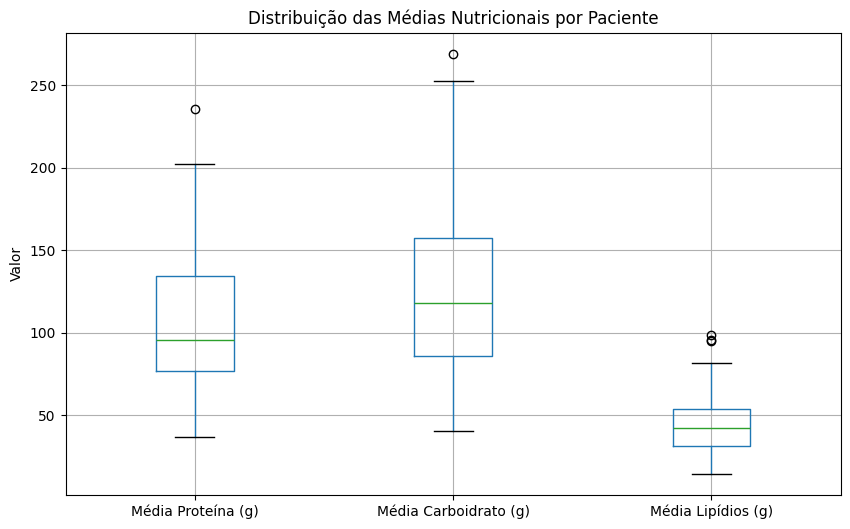

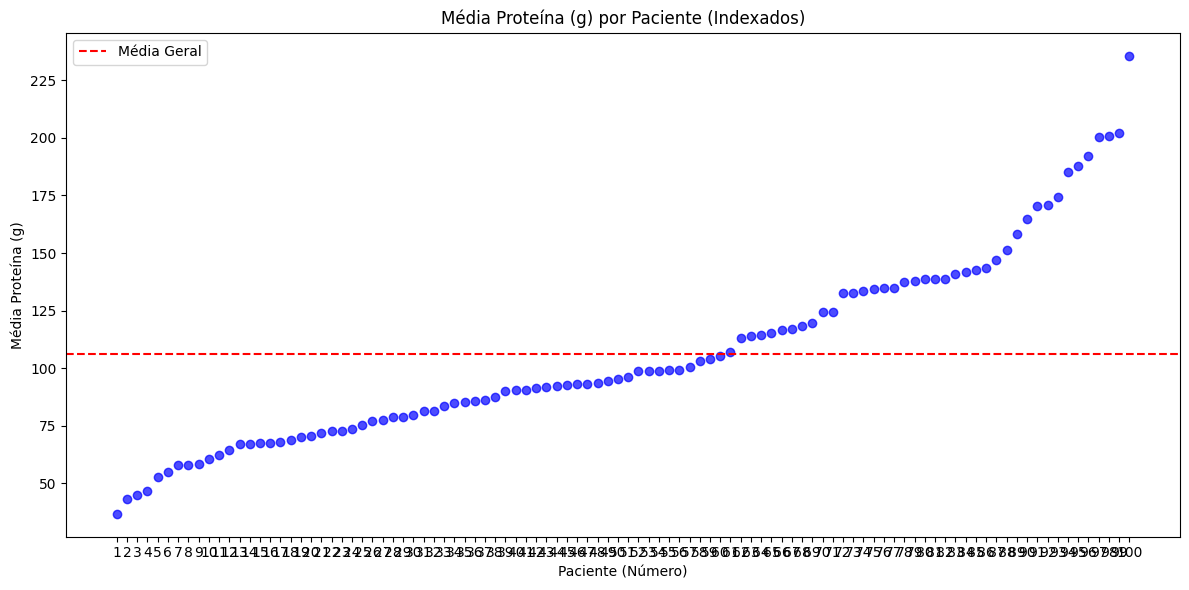

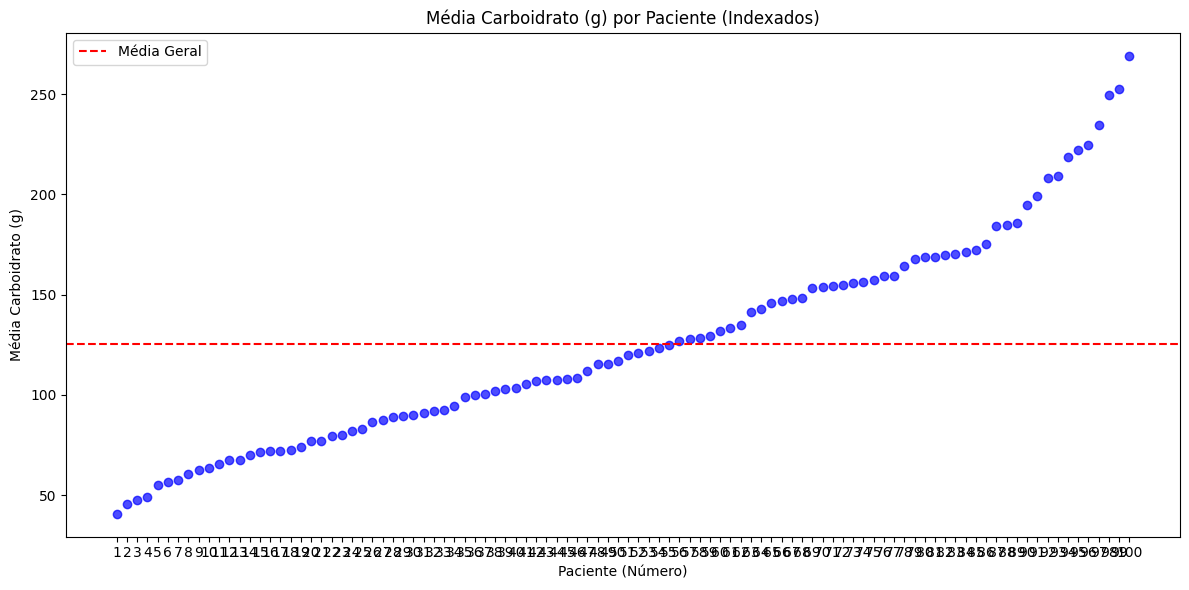

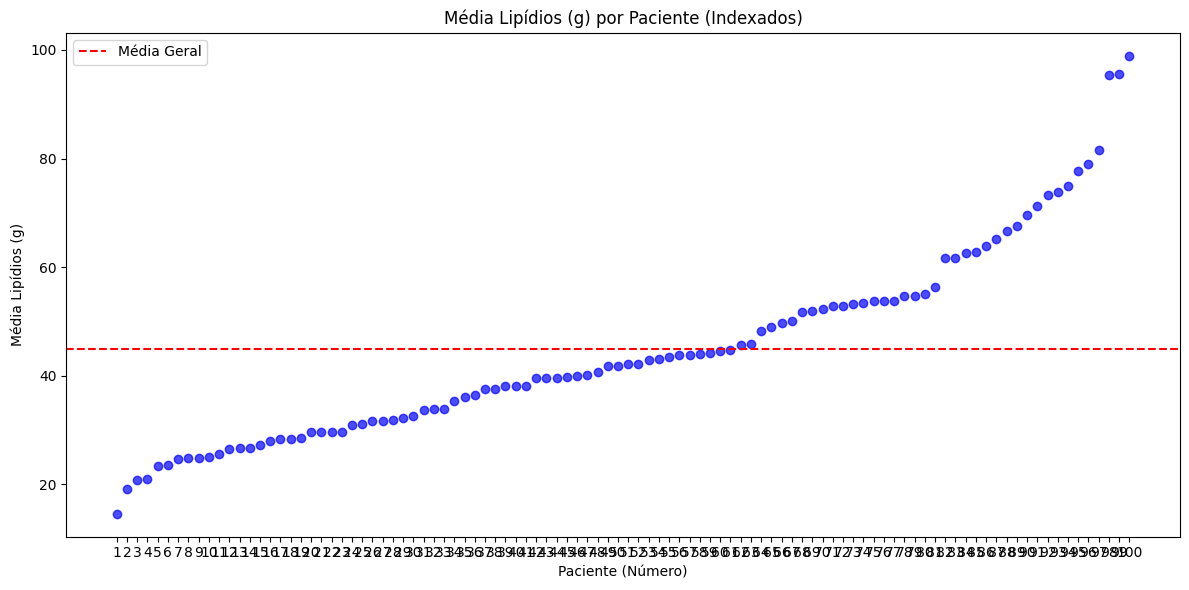

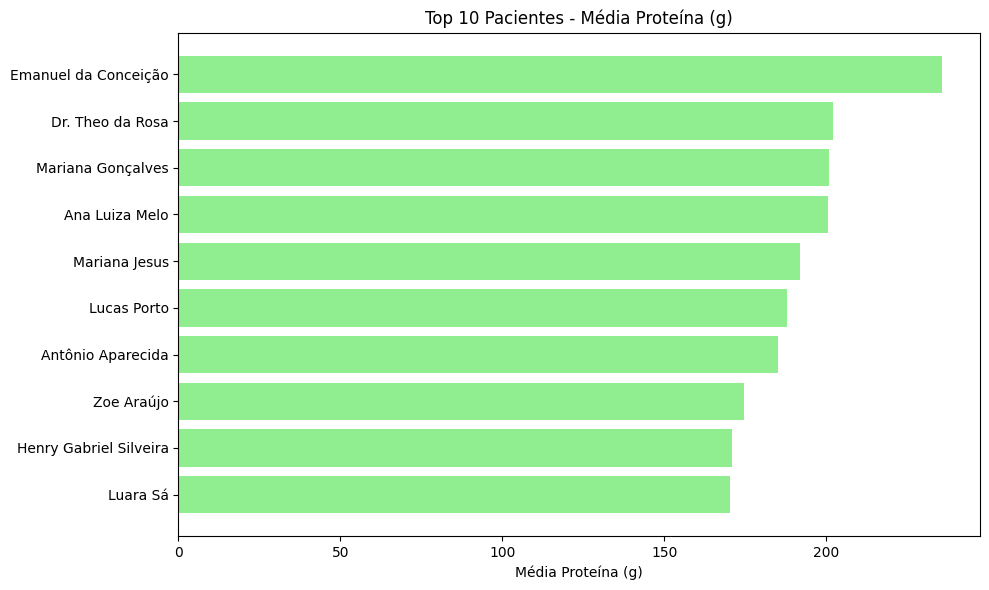

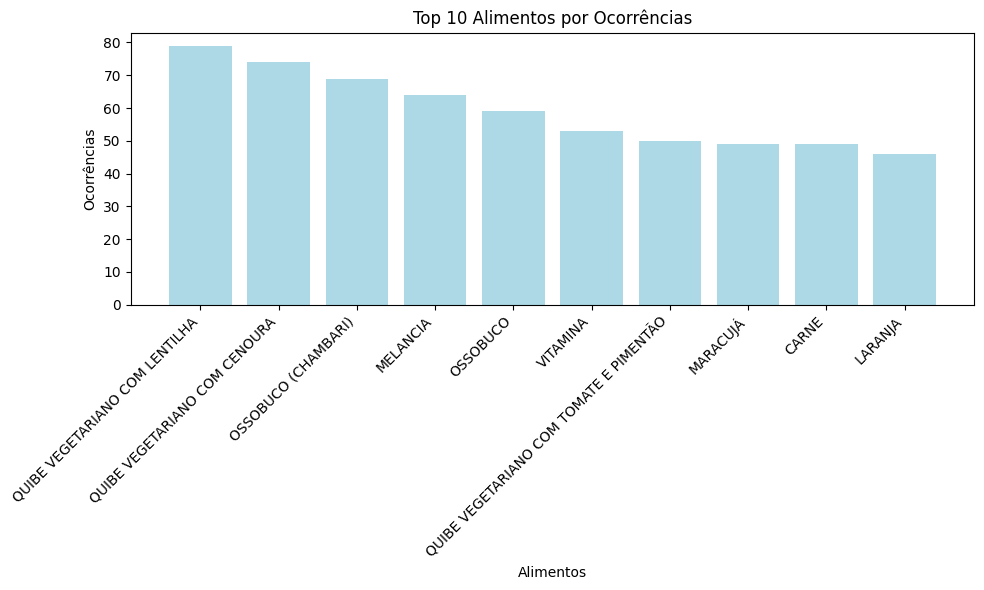

In [180]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_boxplots_medias(df):
    """
    Gera boxplots para as médias dos macronutrientes (Proteína, Carboidrato e Lipídios)
    por paciente, excluindo a linha 'Média Geral'.
    """
    # Exclui a linha da média geral
    df_filtrado = df[df['Paciente'] != 'Média Geral']
    nutrients = ['Média Proteína (g)', 'Média Carboidrato (g)', 'Média Lipídios (g)']

    plt.figure(figsize=(10, 6))
    df_filtrado[nutrients].boxplot()
    plt.title("Distribuição das Médias Nutricionais por Paciente")
    plt.ylabel("Valor")
    plt.show()


def plot_scatter_medias(df, nutrient):
    # Exclui a linha "Média Geral" e ordena os pacientes pelo nutriente
    df_filtrado = df[df['Paciente'] != 'Média Geral'].sort_values(by=nutrient).reset_index(drop=True)

    # Cria um vetor de índices (0, 1, 2, ...) para o eixo x
    x = range(len(df_filtrado))

    plt.figure(figsize=(12, 6))
    plt.scatter(x, df_filtrado[nutrient], color='blue', alpha=0.7)

    # Usa números (1, 2, 3, ...) para os rótulos do eixo x
    plt.xticks(x, [str(i+1) for i in x])

    plt.title(f"{nutrient} por Paciente (Indexados)")
    plt.xlabel("Paciente (Número)")
    plt.ylabel(nutrient)

    # Obtém o valor da Média Geral para esse nutriente (se existir)
    media_geral = df[df['Paciente'] == 'Média Geral'][nutrient]
    if not media_geral.empty:
        plt.axhline(y=media_geral.values[0], color='red', linestyle='--', label="Média Geral")
        plt.legend()

    plt.tight_layout()
    plt.show()


def plot_top_n_medias(df, nutrient, top_n=10):
    """
    Gera um gráfico de barras horizontal para os top N pacientes em relação a um macronutriente.
    """
    df_filtrado = df[df['Paciente'] != 'Média Geral']
    df_sorted = df_filtrado.sort_values(by=nutrient, ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.barh(df_sorted['Paciente'], df_sorted[nutrient], color='lightgreen')
    plt.xlabel(nutrient)
    plt.title(f"Top {top_n} Pacientes - {nutrient}")
    plt.gca().invert_yaxis()  # Maior valor no topo
    plt.tight_layout()
    plt.show()

def plot_ocorrencias_alimentos(df_alimentos_agregado, top_n=10):
    """
    Gera um gráfico de barras vertical para as ocorrências de alimentos.
    Exibe os top N alimentos com maior ocorrência.
    """
    # Ordena os alimentos por Ocorrências de forma decrescente e seleciona os top N
    df_sorted = df_alimentos_agregado.sort_values(by='Ocorrências', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.bar(df_sorted['Alimento'], df_sorted['Ocorrências'], color='lightblue')
    plt.title("Top {} Alimentos por Ocorrências".format(top_n))
    plt.xlabel("Alimentos")
    plt.ylabel("Ocorrências")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Exemplo de uso:
# Supondo que 'df_medias_gerais' seja o DataFrame com as médias nutricionais por paciente
# (incluindo uma linha 'Média Geral' para os dados agregados).

# Plotar boxplots para os macronutrientes
plot_boxplots_medias(df_medias_gerais)

# Plotar gráfico de dispersão para a média de proteína
plot_scatter_medias(df_medias_gerais, 'Média Proteína (g)')

# Plotar gráfico de dispersão para a média de carboidrato
plot_scatter_medias(df_medias_gerais, 'Média Carboidrato (g)')

# Plotar gráfico de dispersão para a média de Lipídios
plot_scatter_medias(df_medias_gerais, 'Média Lipídios (g)')

# Plotar top 10 pacientes em média de proteína
plot_top_n_medias(df_medias_gerais, 'Média Proteína (g)', top_n=10)

plot_ocorrencias_alimentos(df_alimentos_agregado, top_n=10)



Loop Principal do NSGA-II

In [181]:
def get_base_name(food_name):
    # Extrai a primeira palavra, removendo vírgulas e espaços extras, e converte para maiúsculas.
    return food_name.split()[0].strip(' ,').upper()

class WeeklyDietProblem(Problem):
    def __init__(self, df, n_days, n_meals, n_foods_per_meal, daily_caloric_target, energy_weight=10.0, min_energy_ratio=0.9):
        """
        Parâmetros:
          - df: DataFrame com os alimentos.
          - n_days: número de dias (ex.: 5).
          - n_meals: número de refeições por dia.
          - n_foods_per_meal: número de alimentos em cada refeição.
          - daily_caloric_target: meta de kcal por dia (por exemplo, a TMB do paciente).
          - energy_weight: fator multiplicador para o desvio calórico (objetivo).
          - min_energy_ratio: fração da meta que deve ser atingida (ex.: 0.9 para 90% da meta).
        """
        self.df = df.reset_index(drop=True)
        self.n_days = n_days
        self.n_meals = n_meals
        self.n_foods_per_meal = n_foods_per_meal
        self.daily_caloric_target = daily_caloric_target
        self.energy_weight = energy_weight
        self.min_energy_ratio = min_energy_ratio

        self.total_foods = n_days * n_meals * n_foods_per_meal

        # Agora temos 5 objetivos e 3 restrições por dia:
        # 1) Energia inferior: min_energy - day_energy <= 0
        # 2) Energia superior: day_energy - daily_caloric_target <= 0
        # 3) Duplicatas: (número de alimentos - número de únicos) <= 0
        super().__init__(
            n_var=self.total_foods,
            n_obj=5,
            n_constr=n_days * 3,  # 3 restrições por dia
            xl=np.zeros(self.total_foods),
            xu=np.full(self.total_foods, len(df) - 1),
            type_var=int
        )

    def _evaluate(self, X, out, *args, **kwargs):
        obj_protein = []    # Minimizar -proteína (ou seja, maximizar proteína)
        obj_carb = []       # Minimizar carboidratos
        obj_lipids = []     # Minimizar lipídios
        obj_fibras = []     # Minimizar -fibras (ou seja, maximizar fibras)
        obj_energy_dev = [] # Minimizar o desvio calórico ponderado
        constraints = []    # Lista de restrições para cada dia

        for sol in X:
            total_protein = 0
            total_carb = 0
            total_lipids = 0
            total_fibras = 0
            total_energy_dev = 0
            sol_constraints = []

            for d in range(self.n_days):
                start = d * self.n_meals * self.n_foods_per_meal
                end = start + self.n_meals * self.n_foods_per_meal
                sol_day = sol[start:end]
                selected_day = self.df.iloc[sol_day]

                day_energy = selected_day["ENERGIA KCAL"].sum()

                # Restrição Inferior: exige que a energia do dia seja >= min_energy.
                min_energy = self.daily_caloric_target * self.min_energy_ratio
                lower_constraint = min_energy - day_energy  # ≤ 0 se day_energy >= min_energy

                # Restrição Superior: exige que a energia do dia seja <= daily_caloric_target.
                upper_constraint = day_energy - self.daily_caloric_target  # ≤ 0 se day_energy <= target

                # Acumula o desvio energético (objetivo): como queremos que day_energy seja o mais próximo possível de daily_caloric_target,
                # usamos o desvio (daily_caloric_target - day_energy) e o peso.
                energy_deviation = self.daily_caloric_target - day_energy
                total_energy_dev += energy_deviation * self.energy_weight

                # Restrição de Duplicidade: Penaliza repetições com base na primeira palavra.
                foods_day = selected_day["ALIMENTO"].tolist()
                base_names = [get_base_name(food) for food in foods_day]
                duplicate_constraint = len(base_names) - len(set(base_names))

                sol_constraints.extend([lower_constraint, upper_constraint, duplicate_constraint])

                total_protein += selected_day["PROTEÍNA"].sum()
                total_carb += selected_day["CARBOIDRATO TOTAL"].sum()
                total_lipids += selected_day["LIPÍDIOS"].sum()
                total_fibras += selected_day["FIBRA ALIMENTAR"].sum()

            obj_protein.append(-total_protein)
            obj_carb.append(total_carb)
            obj_lipids.append(total_lipids)
            obj_fibras.append(-total_fibras)
            obj_energy_dev.append(total_energy_dev)

            constraints.append(sol_constraints)

        out["F"] = np.column_stack([obj_protein, obj_carb, obj_lipids, obj_fibras, obj_energy_dev])
        out["G"] = np.array(constraints)


In [194]:
def resumir_nome_alimento(nome):
    """
    Recebe uma string com o nome completo do alimento e retorna
    uma versão resumida com apenas a primeira parte e a primeira palavra
    da segunda parte, tudo em minúsculas.

    Exemplo:
      "SALADA, CHUCHU COZIDO, CEBOLA, C/ MOLHO VINAGRETE (...)"
      -> "salada chuchu"
    """
    partes = [parte.strip() for parte in nome.lower().split(',')]
    if len(partes) < 2:
        return nome.lower().strip()
    primeiro = partes[0]
    # Verifica se a segunda parte possui ao menos uma palavra
    palavras_segundo = partes[1].split()
    if not palavras_segundo:
        return primeiro
    segundo = palavras_segundo[0]
    return f"{primeiro} {segundo}"


def resumir_nomes_alimentos(food_list):
    """
    Recebe uma lista de nomes de alimentos e retorna uma nova lista com os nomes resumidos.
    """
    return [resumir_nome_alimento(food) for food in food_list]

def map_to_two_meal_types(tipo):
    if "Café" in tipo or "Lanche" in tipo:
        return "Café da Manhã/Lanche"
    else:
        return "Almoço/Jantar"
def display_weekly_solution(solution, df, n_days, n_meals, n_foods_per_meal):
    day_names = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira"]

    total_foods = n_days * n_meals * n_foods_per_meal
    if len(solution) != total_foods:
        print("A solução possui dimensão diferente da esperada!")
        return

    solution = list(map(int, solution))

    for d in range(n_days):
        start_day = d * n_meals * n_foods_per_meal
        end_day = start_day + n_meals * n_foods_per_meal
        day_solution = solution[start_day:end_day]
        day_df = df.iloc[day_solution]
        total_cal = day_df["ENERGIA KCAL"].sum()
        total_protein = day_df["PROTEÍNA"].sum()
        total_carb = day_df["CARBOIDRATO TOTAL"].sum()
        total_lipids = day_df["LIPÍDIOS"].sum()
        total_fibras = day_df["FIBRA ALIMENTAR"].sum()

        foods_day = day_df["ALIMENTO"].tolist()


        print(f"{day_names[d]}:")
        print(f"  Calorias Totais: {total_cal:.2f} kcal")
        print("  Alimentos utilizados: " + ", ".join(foods_day))
        print(f"  Proteína Total do Dia: {total_protein:.2f} g")
        print(f"  Carboidrato Total do Dia: {total_carb:.2f} g")
        print(f"  Lipídios Totais do Dia: {total_lipids:.2f} g")
        print(f"  Fibras Totais do Dia: {total_fibras:.2f} g")
        print("  Refeições:")

        for m in range(n_meals):
            start_meal = start_day + m * n_foods_per_meal
            end_meal = start_meal + n_foods_per_meal
            meal_solution = solution[start_meal:end_meal]
            meal_df = df.iloc[meal_solution]
            meal_cal = meal_df["ENERGIA KCAL"].sum()
            meal_protein = meal_df["PROTEÍNA"].sum()
            meal_carb = meal_df["CARBOIDRATO TOTAL"].sum()
            meal_lipids = meal_df["LIPÍDIOS"].sum()
            meal_fibras = meal_df["FIBRA ALIMENTAR"].sum()
            meal_foods = meal_df["ALIMENTO"].tolist()
            #meal_foods = resumir_nomes_alimentos(meal_df["ALIMENTO"].tolist())

            print(f"    - Refeição {m+1}: {meal_cal:.2f} kcal")
            for food, cal, prot, carb, fib, lip in zip(meal_foods,
                                                      meal_df["ENERGIA KCAL"],
                                                      meal_df["PROTEÍNA"],
                                                      meal_df["CARBOIDRATO TOTAL"],
                                                      meal_df["FIBRA ALIMENTAR"],
                                                      meal_df["LIPÍDIOS"]):
                print(f"      * {food}: {cal:.2f} kcal, P: {prot:.2f} g, C: {carb:.2f} g, F: {fib:.2f} g, L: {lip:.2f} g")
        print()




In [195]:
def calcular_resumo_nutricional_semana(result, df, n_days, n_meals, n_foods_per_meal):
    """
    Calcula os totais nutricionais da semana com base na melhor solução do NSGA-II.
    Retorna um dicionário com os totais de calorias, proteína, carboidrato, lipídios e fibras.
    """
    # Seleciona a melhor solução (vetor de índices)
    best_solution = result.X[0]

    total_calorias = 0
    total_proteina = 0
    total_carboidrato = 0
    total_lipideos = 0
    total_fibras = 0

    # Para cada dia, acumula os valores nutricionais
    for d in range(n_days):
        start = d * n_meals * n_foods_per_meal
        end = start + n_meals * n_foods_per_meal
        # Seleciona os alimentos correspondentes a esse dia
        day_indices = best_solution[start:end]
        day_df = df.iloc[day_indices]
        total_calorias += day_df["ENERGIA KCAL"].sum()
        total_proteina += day_df["PROTEÍNA"].sum()
        total_carboidrato += day_df["CARBOIDRATO TOTAL"].sum()
        total_lipideos += day_df["LIPÍDIOS"].sum()
        total_fibras += day_df["FIBRA ALIMENTAR"].sum()

    return {
        'calorias_total_semana': total_calorias,
        'proteina_total_semana': total_proteina,
        'carboidrato_total_semana': total_carboidrato,
        'lipidios_total_semana': total_lipideos,
        'fibras_total_semana': total_fibras
    }


In [196]:
def resumir_nome_alimento(nome):
    """
    Recebe uma string com o nome completo do alimento e retorna
    uma versão resumida com apenas a primeira parte e a primeira palavra
    da segunda parte, tudo em minúsculas.

    Exemplo:
      "SALADA, CHUCHU COZIDO, CEBOLA, C/ MOLHO VINAGRETE (...)"
      -> "salada chuchu"
    """
    partes = [parte.strip() for parte in nome.upper().split(',')]
    if len(partes) < 2:
        return nome.upper().strip()
    primeiro = partes[0]
    segundo = partes[1].split()[0]  # pega somente a primeira palavra da segunda parte
    return f"{primeiro} {segundo}"

def gerar_tabelas_latex_dieta_semanal_paciente(solution, df, n_days, n_meals, n_foods_per_meal):
    """
    Gera tabelas LaTeX para a solução semanal da dieta.
    Cada tabela representa um dia da semana (de Segunda a Sexta) e apresenta as informações nutricionais.

    Parâmetros:
      - solution: lista/array com os índices dos alimentos escolhidos (deve ter n_days * n_meals * n_foods_per_meal elementos)
      - df: DataFrame com as informações dos alimentos (colunas: "ALIMENTO", "ENERGIA KCAL", "PROTEÍNA", "CARBOIDRATO TOTAL", "LIPÍDIOS", etc.)
      - n_days: número de dias (ex.: 5 para segunda a sexta)
      - n_meals: número de refeições por dia (utilizado para estruturar a solução)
      - n_foods_per_meal: número de alimentos por refeição

    Retorna:
      Uma string contendo o código LaTeX com as tabelas para cada dia.
    """
    day_names = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira"]
    total_foods = n_days * n_meals * n_foods_per_meal

    if len(solution) != total_foods:
        return "A solução possui dimensão diferente da esperada!"

    # Converte a solução para inteiros
    solution = list(map(int, solution))
    latex_output = ""

    # Para cada dia
    for d in range(n_days):
        start_day = d * n_meals * n_foods_per_meal
        end_day = start_day + n_meals * n_foods_per_meal
        day_solution = solution[start_day:end_day]
        day_df = df.iloc[day_solution]

        # Totais nutricionais do dia
        total_cal = day_df["ENERGIA KCAL"].sum()
        total_protein = day_df["PROTEÍNA"].sum()
        total_carb = day_df["CARBOIDRATO TOTAL"].sum()
        total_lipids = day_df["LIPÍDIOS"].sum()

        lines = []
        lines.append("\\begin{table}[H]")
        lines.append(f"\\caption{{{day_names[d]}}}")
        lines.append("\\centering")
        lines.append("\\begin{tabular}{lrrrrr}")
        lines.append("\\toprule")
        lines.append("Alimento & Quantidade & Calorias (kcal) & Proteína (g) & Carboidrato (g) & Lipídios (g) \\\\")
        lines.append("\\midrule")

        # Para cada refeição do dia (a estrutura continua, sem a referência à refeição)
        for m in range(n_meals):
            start_meal = start_day + m * n_foods_per_meal
            end_meal = start_meal + n_foods_per_meal
            meal_solution = solution[start_meal:end_meal]
            meal_df = df.iloc[meal_solution]
            for idx, row in meal_df.iterrows():
                food = row["ALIMENTO"]
                # Resumindo o nome do alimento:
                #food = resumir_nome_alimento(food)
                quantidade = 1  # Caso não haja informação de quantidade, define 1 por padrão
                cal = row["ENERGIA KCAL"]
                prot = row["PROTEÍNA"]
                carb = row["CARBOIDRATO TOTAL"]
                lip = row["LIPÍDIOS"]
                line = f"{food} & {quantidade} & {cal:.2f} & {prot:.2f} & {carb:.2f} & {lip:.2f} \\\\"
                lines.append(line)

        # Linha com os totais do dia
        lines.append("\\midrule")
        lines.append(f"\\multicolumn{{2}}{{l}}{{Total do Dia}} & {total_cal:.2f} & {total_protein:.2f} & {total_carb:.2f} & {total_lipids:.2f} \\\\")
        lines.append("\\bottomrule")
        lines.append("\\end{tabular}")
        lines.append("\\end{table}")
        lines.append("")  # Linha em branco para separar as tabelas

        latex_output += "\n".join(lines) + "\n\n"

    return latex_output


In [ ]:
dietas_por_paciente = {}
dias_semana = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira"]
n_days = len(dias_semana)
tabelas_latex_paciente ={}

import time

# Inicia a medição do tempo
tempo_inicial = time.perf_counter()

for pa in lista_pacientes_alimento:
    paciente = pa.getPaciente()
    nome = paciente.getNome() if hasattr(paciente, "getNome") else str(paciente)

    n_meals = paciente.getConsistencia_alimentar_aceita()  # Número de refeições por dia
    n_foods_per_meal = random.randint(1, 5)                # Alimentos por refeição
    daily_caloric_target = paciente.getTMB()               # Meta calórica diária (TMB)

    df = pa.gerar_dataframe_alimentos(colunas_relevantes, colunas_numericas)
    df = preprocessamento(df)
    df = categorizar_alimentos_completa(df)
    df['TIPO_REFEICAO_MAPEADO'] = df['TIPO_REFEIÇÃO'].apply(map_to_two_meal_types)

    '''
    print(f"\n=== Processando dieta NSGA-II para {nome} ===")
    print("Número de alimentos disponíveis:", len(df))
    print(f"Número de refeições: {n_meals}")
    print(f"Alimentos por refeição: {n_foods_per_meal}")
    print(f"Meta calórica total: {daily_caloric_target} kcal")
    '''
    # Parâmetros extras para o problema:
    energy_weight = 10.0
    min_energy_ratio = 0.9

    problem = WeeklyDietProblem(df, n_days, n_meals, n_foods_per_meal, daily_caloric_target, energy_weight, min_energy_ratio)
    algorithm = NSGA2(pop_size=200)
    termination = get_termination("n_gen", 200)
    res = minimize(problem, algorithm, termination, seed=1, verbose=False)

    if res.X is not None and len(res.X) > 0:
        best_solution = res.X[0]
        #print("Plano Semanal Otimizado:")
        display_weekly_solution(best_solution, df, n_days, n_meals, n_foods_per_meal)
        tabelas_latex = gerar_tabelas_latex_dieta_semanal_paciente(best_solution, df, n_days, n_meals, n_foods_per_meal)
        tabelas_latex_paciente[nome] = tabelas_latex
        # Calcula o resumo nutricional a partir da melhor solução e armazena-o
        resumo_nutricional = calcular_resumo_nutricional_semana(res, df, n_days, n_meals, n_foods_per_meal)
    else:
        print("Nenhuma solução foi encontrada.")
        resumo_nutricional = None  # ou valores padrão

    dietas_por_paciente[nome] = {
        'resultado_nsga2': res,
        'df_alimentos': df,
        'resumo_nutricional': resumo_nutricional
    }
tempo_final = time.perf_counter()
print(f"\nTempo de execução total: {tempo_final - tempo_inicial:.2f} segundos")

Segunda-feira:
  Calorias Totais: 1691.00 kcal
  Alimentos utilizados: CHUCHU, S/ CASCA, COZIDO, C/ MOLHO BRANCO (FARINHA DE TRIGO, MANTEIGA E LEITE), GRATINADO, C/ QUEIJO PARMESÃO, C/ SAL, , MOLHO, ITALIAN, KENKO, , PEQUI, POLPA, COZIDO, S/ ÓLEO, S/ SAL, CARYOCAR BRASILIENSE, , BROTO DE ALFAFA, C/ ÓLEO DE SOJA, C/ SAL, , ESPETO DE QUEIJO DE MUÇARELA DE BÚFALA, C/ TOMATE E MANJERICÃO, GRELHADO, S/ ÓLEO, , CHOCOLATE, AO LEITE, COM CASTANHA DO BRASIL, 
  Proteína Total do Dia: 32.91 g
  Carboidrato Total do Dia: 89.21 g
  Lipídios Totais do Dia: 136.60 g
  Fibras Totais do Dia: 15.54 g
  Refeições:
    - Refeição 1: 502.00 kcal
      * CHUCHU, S/ CASCA, COZIDO, C/ MOLHO BRANCO (FARINHA DE TRIGO, MANTEIGA E LEITE), GRATINADO, C/ QUEIJO PARMESÃO, C/ SAL, : 76.00 kcal, P: 2.87 g, C: 6.83 g, F: 1.14 g, L: 4.35 g
      * MOLHO, ITALIAN, KENKO, : 426.00 kcal, P: 1.31 g, C: 8.95 g, F: 0.00 g, L: 42.80 g
    - Refeição 2: 407.00 kcal
      * PEQUI, POLPA, COZIDO, S/ ÓLEO, S/ SAL, CARYOCAR BRASIL

In [ ]:
dias_semana = ["Segunda-feira", "Terça-feira", "Quarta-feira", "Quinta-feira", "Sexta-feira"]

for pa in lista_pacientes_alimento:
    paciente_obj = pa.getPaciente()
    nome = paciente_obj.getNome() if hasattr(paciente_obj, "getNome") else str(paciente_obj)
    tabelas_latex = tabelas_latex_paciente.get(nome, "")

    #print(f"\n=== Tabelas LaTeX para {nome} ===\n")
    ficha_nutricional = paciente_obj.converter_latex()
    print(ficha_nutricional)
    print(tabelas_latex)

In [ ]:
def calcular_medias_por_paciente(dietas_por_paciente, dias=5):
    """
    Calcula as médias diárias dos macronutrientes e fibras para cada paciente.
    Assume que cada dieta semanal cobre 'dias' (padrão: 5 dias).
    Retorna um DataFrame com as médias por paciente.
    Se o resumo nutricional não for encontrado, utiliza 0 como valor padrão.
    """
    medias = []
    for nome, dieta in dietas_por_paciente.items():
        resumo = dieta.get('resumo_nutricional', {
            'calorias_total_semana': 0,
            'proteina_total_semana': 0,
            'carboidrato_total_semana': 0,
            'lipidios_total_semana': 0,
            'fibras_total_semana': 0
        })
        medias.append({
            'Paciente': nome,
            'Média Calorias (kcal)': resumo.get('calorias_total_semana', 0) / dias,
            'Média Proteína (g)': resumo.get('proteina_total_semana', 0) / dias,
            'Média Carboidrato (g)': resumo.get('carboidrato_total_semana', 0) / dias,
            'Média Lipídios (g)': resumo.get('lipidios_total_semana', 0) / dias,
            'Média Fibras (g)': resumo.get('fibras_total_semana', 0) / dias
        })
    return pd.DataFrame(medias)


In [ ]:
def resultados_dietas(dietas_por_paciente):
    """
    Recebe um dicionário com as dietas semanais de cada paciente (valor: dieta_semanal)
    e retorna um DataFrame onde cada linha representa um alimento selecionado em uma refeição,
    contendo informações como dia, refeição, alimento, quantidade e macronutrientes.

    Se a chave 'dias' não existir, assume que o próprio dicionário dieta_semanal possui os dias como chaves.
    """
    resultados = []
    for paciente, dieta in dietas_por_paciente.items():
        # Verifica se a estrutura possui a chave 'dias'
        if 'dias' in dieta:
            dias_dict = dieta['dias']
        else:
            dias_dict = dieta  # assume que a própria dieta possui os dias como chaves

        for dia, info_dia in dias_dict.items():
            for refeicao in info_dia['refeicoes']:
                # Supondo que "refeicao" seja um objeto com atributo "nome" e "alimentos" é uma lista de dicionários
                for alimento in refeicao.alimentos:
                    resultados.append({
                        'Paciente': paciente,
                        'Dia': dia,
                        'Refeição': refeicao.nome,
                        # Usa apenas a primeira parte do nome para evitar duplicidade
                        'Alimento': alimento['ALIMENTO'].split(',')[0].strip(),
                        'Quantidade': alimento.get('Quantidade', 1),
                        'Calorias': alimento.get('ENERGIA KCAL', 0),
                        'Proteína': alimento.get('PROTEÍNA', 0),
                        'Carboidrato': alimento.get('CARBOIDRATO TOTAL', 0),
                        'Lipídios': alimento.get('LIPÍDIOS', 0)
                    })
    return pd.DataFrame(resultados)


In [ ]:
# Seleciona as colunas de interesse
colunas = ['Quantidade', 'Calorias', 'Proteína', 'Carboidrato', 'Lipídios']
estatisticas = df_resultados[colunas].describe()

print("Estatísticas Descritivas:")
print(estatisticas)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_boxplots_medias(df):
    """
    Gera boxplots para as médias dos macronutrientes (Proteína, Carboidrato e Lipídios)
    por paciente, excluindo a linha 'Média Geral'.
    """
    # Exclui a linha da média geral
    df_filtrado = df[df['Paciente'] != 'Média Geral']
    nutrients = ['Média Proteína (g)', 'Média Carboidrato (g)', 'Média Lipídios (g)']

    plt.figure(figsize=(10, 6))
    df_filtrado[nutrients].boxplot()
    plt.title("Distribuição das Médias Nutricionais por Paciente")
    plt.ylabel("Valor")
    plt.tight_layout()
    plt.show()


def plot_scatter_medias(df, nutrient):
    """
    Gera um gráfico de dispersão para a média de um nutriente específico, sem exibir os nomes dos pacientes.
    Ordena os pacientes pelo valor do nutriente e exibe o índice (1, 2, 3, ...) no eixo x.
    """
    # Exclui a linha "Média Geral" e ordena pelo nutriente
    df_filtrado = df[df['Paciente'] != 'Média Geral'].sort_values(by=nutrient).reset_index(drop=True)
    x = range(len(df_filtrado))

    plt.figure(figsize=(12, 6))
    plt.scatter(x, df_filtrado[nutrient], color='blue', alpha=0.7)
    # Exibe números (1, 2, 3, ...) para os rótulos do eixo x
    plt.xticks(x, [str(i+1) for i in x])
    plt.title(f"{nutrient} por Paciente (Indexados)")
    plt.xlabel("Paciente (Número)")
    plt.ylabel(nutrient)

    # Adiciona linha com o valor da 'Média Geral' (se existir)
    media_geral = df[df['Paciente'] == 'Média Geral'][nutrient]
    if not media_geral.empty:
        plt.axhline(y=media_geral.values[0], color='red', linestyle='--', label="Média Geral")
        plt.legend()

    plt.tight_layout()
    plt.show()


def plot_top_n_medias(df, nutrient, top_n=10):
    """
    Gera um gráfico de barras horizontal para os top N pacientes em relação a um macronutriente.
    Exibe os nomes dos pacientes (ou a identificação, conforme os dados) e inverte o eixo y
    para que o maior valor fique no topo.
    """
    df_filtrado = df[df['Paciente'] != 'Média Geral']
    df_sorted = df_filtrado.sort_values(by=nutrient, ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    # Utiliza a coluna 'Paciente' para os rótulos no eixo y e o valor do nutriente para as barras
    plt.barh(df_sorted['Paciente'], df_sorted[nutrient], color='lightgreen')
    plt.xlabel(nutrient)
    plt.title(f"Top {len(df_sorted)} Pacientes - {nutrient}")
    plt.gca().invert_yaxis()  # Maior valor no topo
    plt.tight_layout()
    plt.show()


def plot_ocorrencias_alimentos(df_alimentos_agregado, top_n=10):
    """
    Gera um gráfico de barras vertical para as ocorrências de alimentos.
    Exibe os top N alimentos com maior ocorrência e rotaciona os rótulos do eixo x para melhor visualização.
    """
    # Ordena os alimentos por 'Ocorrências' de forma decrescente e seleciona os top N
    df_sorted = df_alimentos_agregado.sort_values(by='Ocorrências', ascending=False).head(top_n)

    plt.figure(figsize=(10, 6))
    plt.bar(df_sorted['Alimento'], df_sorted['Ocorrências'], color='lightblue')
    plt.title("Top {} Alimentos por Ocorrências".format(top_n))
    plt.xlabel("Alimentos")
    plt.ylabel("Ocorrências")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Exemplo de uso:
# Suponha que 'df_medias_gerais' seja o DataFrame com as médias nutricionais por paciente,
# incluindo uma linha 'Média Geral' para os dados agregados,
# e 'df_alimentos_agregado' seja o DataFrame com a contagem de ocorrências dos alimentos.

# Plotar boxplots para os macronutrientes
plot_boxplots_medias(df_medias_gerais)

# Plotar gráfico de dispersão para a média de proteína
plot_scatter_medias(df_medias_gerais, 'Média Proteína (g)')

# Plotar gráfico de dispersão para a média de carboidrato
plot_scatter_medias(df_medias_gerais, 'Média Carboidrato (g)')

# Plotar gráfico de dispersão para a média de lipídios
plot_scatter_medias(df_medias_gerais, 'Média Lipídios (g)')

# Plotar top 10 pacientes em média de proteína
plot_top_n_medias(df_medias_gerais, 'Média Proteína (g)', top_n=10)

# Plotar ocorrências de alimentos
plot_ocorrencias_alimentos(df_alimentos_agregado, top_n=10)
